#### NutriGlyc AI: Predicting Diabetes Risk and Glucose Spikes Using Machine Learning
#####   By Olayemi Balogun

##### Business Introduction
NutriGlyc AI Solutions is a health technology and nutrition analytics company based in California, USA. The company uses artificial intelligence, machine learning, and nutrition science to help prevent and manage Type 2 Diabetes.

##### Problem Statement
- Rising cases of Type 2 Diabetes and nutrition-related diseases
- Delayed diagnosis and limited preventive healthcare support
- Difficulty identifying high-risk individuals early
- Lack of data-driven nutrition and risk assessment tools
- Need for personalized recommendations to improve health outcomes

##### Project Objectives

- Predict glucose spikes using machine learning.
- Identify major diabetes risk factors.
- Provide personalized nutrition insights.
- Support early intervention and preventive healthcare.

##### Import the libraries

In [87]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import missingno as msno

##### Load the dataset

In [88]:
df = pd.read_excel("Glucose_Spike_Dataset.xlsx")

##### Data Inspection

In [89]:
# Top 5 rows
df.head()

,patient_id,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,...,sleep_hours,smoking_status,alcohol_consumption,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
0,1127,63,Male,25.318753,Type 2,Snack,206.078625,96.988928,81.332092,19.881550,...,6.038772,Yes,No,80.511484,185.125157,104.613673,139.121175,10.313445,2.057729,1
1,861,43,Female,29.887205,Type 1,Snack,110.277131,41.988332,65.323781,9.660801,...,7.787871,No,No,102.325117,101.612905,-0.712212,80.057182,11.297959,2.153776,0
2,1131,65,Female,21.831540,Type 1,Breakfast,88.692079,74.612428,26.828247,26.701083,...,9.146882,No,No,99.639334,123.456632,23.817298,46.809459,3.309272,1.309858,0
3,1096,56,Male,26.610861,Type 2,Dinner,168.193534,70.944312,58.451133,23.006694,...,5.856119,No,No,116.822669,122.497946,5.675277,127.919532,7.278996,2.061997,0
4,1045,58,Male,26.649132,Type 2,Dinner,93.580856,74.851625,14.576802,19.789018,...,7.327162,Yes,No,99.878155,98.419762,-1.458393,58.098774,4.705152,1.168034,0


In [90]:
# Bottom 5 rows
df.tail()

,patient_id,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,...,sleep_hours,smoking_status,alcohol_consumption,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
5145,128,52,Male,17.089172,Type 1,Snack,113.399998,63.730627,84.595744,14.292383,...,5.442210,Yes,No,83.287935,107.931203,24.643268,49.173275,7.879168,1.328944,0
5146,143,73,Male,27.745089,Type 2,Snack,195.660539,109.858407,27.575196,18.824318,...,4.311916,No,No,118.782185,160.973903,42.191718,105.310937,10.339106,2.329110,1
5147,803,65,Male,18.788603,Type 2,Dinner,48.522283,56.986410,19.381166,16.691101,...,7.171125,Yes,No,113.424925,143.757116,30.332191,42.726837,2.889762,1.690263,0
5148,246,79,Male,26.539871,Type 2,Snack,102.805482,60.987416,44.298409,21.329768,...,7.713246,No,Yes,92.099547,134.721431,42.621884,44.847135,4.797321,1.354043,1
5149,331,35,Female,24.051558,Type 2,Breakfast,186.755906,78.396761,49.267450,34.102746,...,5.034909,Yes,No,100.561873,161.330950,60.769077,100.459622,5.460261,1.451803,1


In [91]:
# Dimension of the data
df.shape

(5150, 28)

##### Descriptive Analysis

In [92]:
df.describe()

,patient_id,age,bmi,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,glycemic_index,portion_size,...,physical_activity,stress_level,sleep_hours,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
count,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,4841.000000,5150.000000,5150.000000,5150.000000,...,5150.000000,4835.000000,4842.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000,5150.000000
mean,607.980583,48.338835,27.043032,122.520750,59.871306,49.812292,18.101458,46.040899,60.037362,399.110628,...,45.363254,5.478180,6.506480,110.739290,144.715815,33.976525,73.600590,9.751877,1.803309,0.465049
std,345.237485,17.861075,4.980009,58.018989,24.517150,19.601541,7.920562,24.135594,14.672699,120.325387,...,24.236189,2.867306,1.463630,13.543094,32.430293,29.207539,40.322001,12.266698,0.742337,0.498825
min,1.000000,18.000000,16.000000,10.000000,5.000000,5.000000,2.000000,0.000000,30.000000,100.000000,...,0.000000,1.000000,3.000000,70.000000,70.000000,-57.053540,3.000000,0.265554,0.391785,0.000000
25%,312.250000,33.000000,23.629638,81.484340,43.316316,36.355618,12.672105,29.083575,49.810095,319.418417,...,28.351598,3.000000,5.491062,102.024101,122.045551,12.884643,43.833275,4.151556,1.378861,0.000000
50%,616.000000,48.000000,26.986358,121.873969,59.168519,49.692208,17.983936,45.740657,59.860549,399.311839,...,44.866445,5.000000,6.506330,111.004625,143.084070,32.327095,69.551007,6.757980,1.697013,0.000000
75%,906.750000,64.000000,30.430209,163.937671,76.326848,62.698777,23.463788,62.027881,70.489454,478.161253,...,61.824295,8.000000,7.501433,119.941144,165.602878,52.266997,98.526361,10.428609,2.039949,1.000000
max,1200.000000,79.000000,44.093061,319.606832,148.563508,131.989007,48.209951,131.880984,100.000000,807.294680,...,141.502228,10.000000,10.000000,152.885870,273.804356,161.230116,271.344849,152.193730,9.660761,1.000000


In [93]:
df[['water_intake', 'insulin_dose', 'medication_adherence']].describe()

,water_intake,insulin_dose,medication_adherence
count,5150.000000,4839.000000,5150.000000
mean,248.345265,3.473438,0.810097
std,118.196702,1.979170,0.392262
min,0.000000,0.732023,0.000000
25%,166.408367,2.076384,1.000000
50%,243.550770,3.081127,1.000000
75%,328.290687,4.110144,1.000000
max,689.083449,12.719253,1.000000


In [94]:
df.describe(include=["object", "string", "bool"])

,gender,diabetes_type,meal_time,smoking_status,alcohol_consumption
count,5150,5150,5150,5150,5150
unique,2,2,4,2,2
top,Female,Type 2,Dinner,No,No
freq,2695,4397,1331,4125,3832


##### Data Overview
- The dataset contains 5,150 patients details. Most features have complete data but there are missing values in: fiber_intake (4,841 values),stress_level (4,835 values), sleep_hours (4,842 values) and insulin_dose(4839 values). These missing values should be handled before modeling.
- Average age od patient is 48 years, ranging from 18–79 years.
- Average BMI: 27, indicating many patients are overweight.
- Gender distribution is balanced:Female: 52.3% and Male: 47.7%.
- 85.4% of patients have Type 2 Diabetes. Type 1 patients make up a smaller percentage.
- Some patients consume very high amounts of sugar (132g), which could contribute to elevated glucose levels.
- Fiber intake varies from 2g to 48g among patients. Higher fiber intake may help reduce glucose spikes.
- Large variation in water consumption. Some patients report very low or no water intake, while others consume much more. Hydration may be worth investigating as a factor influencing glucose control.
- There is a large variation in carbohydrate consumption with an average of 122.5g, from 10g to 320g, which may influence glucose spikes.
- Higher ratios (152.2 of carb to fibre) suggest meals with many carbohydrates but little fiber, potentially leading to larger glucose spikes.
- 81% of patients follow their medication plan, while about 19% do not.
- Many patients sleep less (Average: 6.5 hours) than the recommended 7–9 hours, which could affect glucose level.
- Most patients experience moderate stress levels (5.5).
- Patients consume foods ranging from low to very high glycemic index levels (30 to 100), making this an important feature.
- Physical activity differs across patients, from low or no physical activity to those having up to 142 minutes exercise, suggesting exercise may play a role in glucose control.
- Many patients start meals with high glucose levels with an average of 111mg/dL, ranging from 70 to 153mg/dL.
- Post-meal glucose levels are higher than pre-meal levels, with an average of 145mg/dL, ranging from 70 to 274mg/dL indicating the impact of food intake.
- Some patients experience very large increases in glucose (161mg/dL) after meals.
- Most meals have very high glycemic loads up to 271.3, which may increase spike risk.
- 46.5% experienced a glucose spike, while 53.5% did not experience a glucose spike.
- 52.3% of the patients are female while the rest are male.
- There are 4 meal times recorded. Dinner is the most common meal, with 1,331 records (25.8%).
- Most patients (80.1%) do not smoke and most patients do not consume alcohol (74.4%), but they can still be analyzed as a potential risk factor for glucose spikes.


##### Data Cleaning

In [95]:
# Check for duplicates
df.duplicated().sum()

np.int64(150)

In [96]:
# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)

In [97]:
df.duplicated().sum()

np.int64(0)

    150 duplicates were found and removed from the data

In [98]:
df.shape

(5000, 28)

In [99]:
# Check for missing data
df.isnull().sum()

patient_id                0
age                       0
gender                    0
bmi                       0
diabetes_type             0
meal_time                 0
carb_intake               0
protein_intake            0
fat_intake                0
fiber_intake            300
sugar_intake              0
glycemic_index            0
portion_size              0
water_intake              0
insulin_dose            300
medication_adherence      0
physical_activity         0
stress_level            300
sleep_hours             300
smoking_status            0
alcohol_consumption       0
pre_meal_glucose          0
post_meal_glucose         0
glucose_change            0
glycemic_load             0
carb_fiber_ratio          0
meal_risk_score           0
glucose_spike             0
dtype: int64

In [100]:
df.isnull().mean()*100

patient_id              0.0
age                     0.0
gender                  0.0
bmi                     0.0
diabetes_type           0.0
meal_time               0.0
carb_intake             0.0
protein_intake          0.0
fat_intake              0.0
fiber_intake            6.0
sugar_intake            0.0
glycemic_index          0.0
portion_size            0.0
water_intake            0.0
insulin_dose            6.0
medication_adherence    0.0
physical_activity       0.0
stress_level            6.0
sleep_hours             6.0
smoking_status          0.0
alcohol_consumption     0.0
pre_meal_glucose        0.0
post_meal_glucose       0.0
glucose_change          0.0
glycemic_load           0.0
carb_fiber_ratio        0.0
meal_risk_score         0.0
glucose_spike           0.0
dtype: float64

In [101]:
# To see the row with the missing value
df[df.isnull().any(axis=1)]

,patient_id,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,...,sleep_hours,smoking_status,alcohol_consumption,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
14,806,53,Female,29.819169,Type 2,Dinner,57.160092,48.605818,77.303979,17.531498,...,6.187077,No,No,113.962146,120.724388,6.762242,38.527314,3.241931,1.026655,0
21,253,75,Female,30.750028,Type 1,Snack,124.626816,76.927840,56.568285,28.463052,...,7.205142,No,No,107.068295,122.105474,15.037179,45.225735,4.363218,1.248998,0
25,1083,62,Female,30.546246,Type 2,Snack,227.845078,48.632714,41.481049,NaN,...,4.900855,No,No,121.992517,234.235160,112.242643,68.353523,21.750719,2.147020,1
31,687,39,Female,22.549559,Type 1,Lunch,202.452979,72.862111,26.838453,10.002851,...,NaN,No,Yes,85.162844,139.026250,53.863405,152.228698,20.039192,2.641016,1
34,832,35,Male,25.260760,Type 2,Dinner,68.143700,60.523469,32.483476,NaN,...,6.035664,No,No,107.624558,109.584360,1.959802,32.821688,2.016789,1.246424,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4932,366,67,Female,29.687729,Type 2,Dinner,182.861859,5.000000,79.122706,NaN,...,7.232978,No,No,119.791677,85.746130,-34.045547,85.832751,5.629968,1.545804,0
4959,507,46,Female,32.023460,Type 2,Lunch,115.173358,70.068306,95.756371,33.085259,...,NaN,Yes,No,117.517583,123.826389,6.308806,88.240628,3.470618,1.568822,0
4967,1193,43,Female,32.386536,Type 2,Dinner,42.977145,48.131929,54.077053,NaN,...,4.670752,Yes,Yes,103.554482,92.416887,-11.137595,31.992795,1.991895,1.391139,0
4969,650,39,Female,16.000000,Type 2,Dinner,219.875199,51.344072,54.265845,19.877143,...,5.448296,No,Yes,93.911929,157.507120,63.595190,97.600914,11.006339,2.078111,1


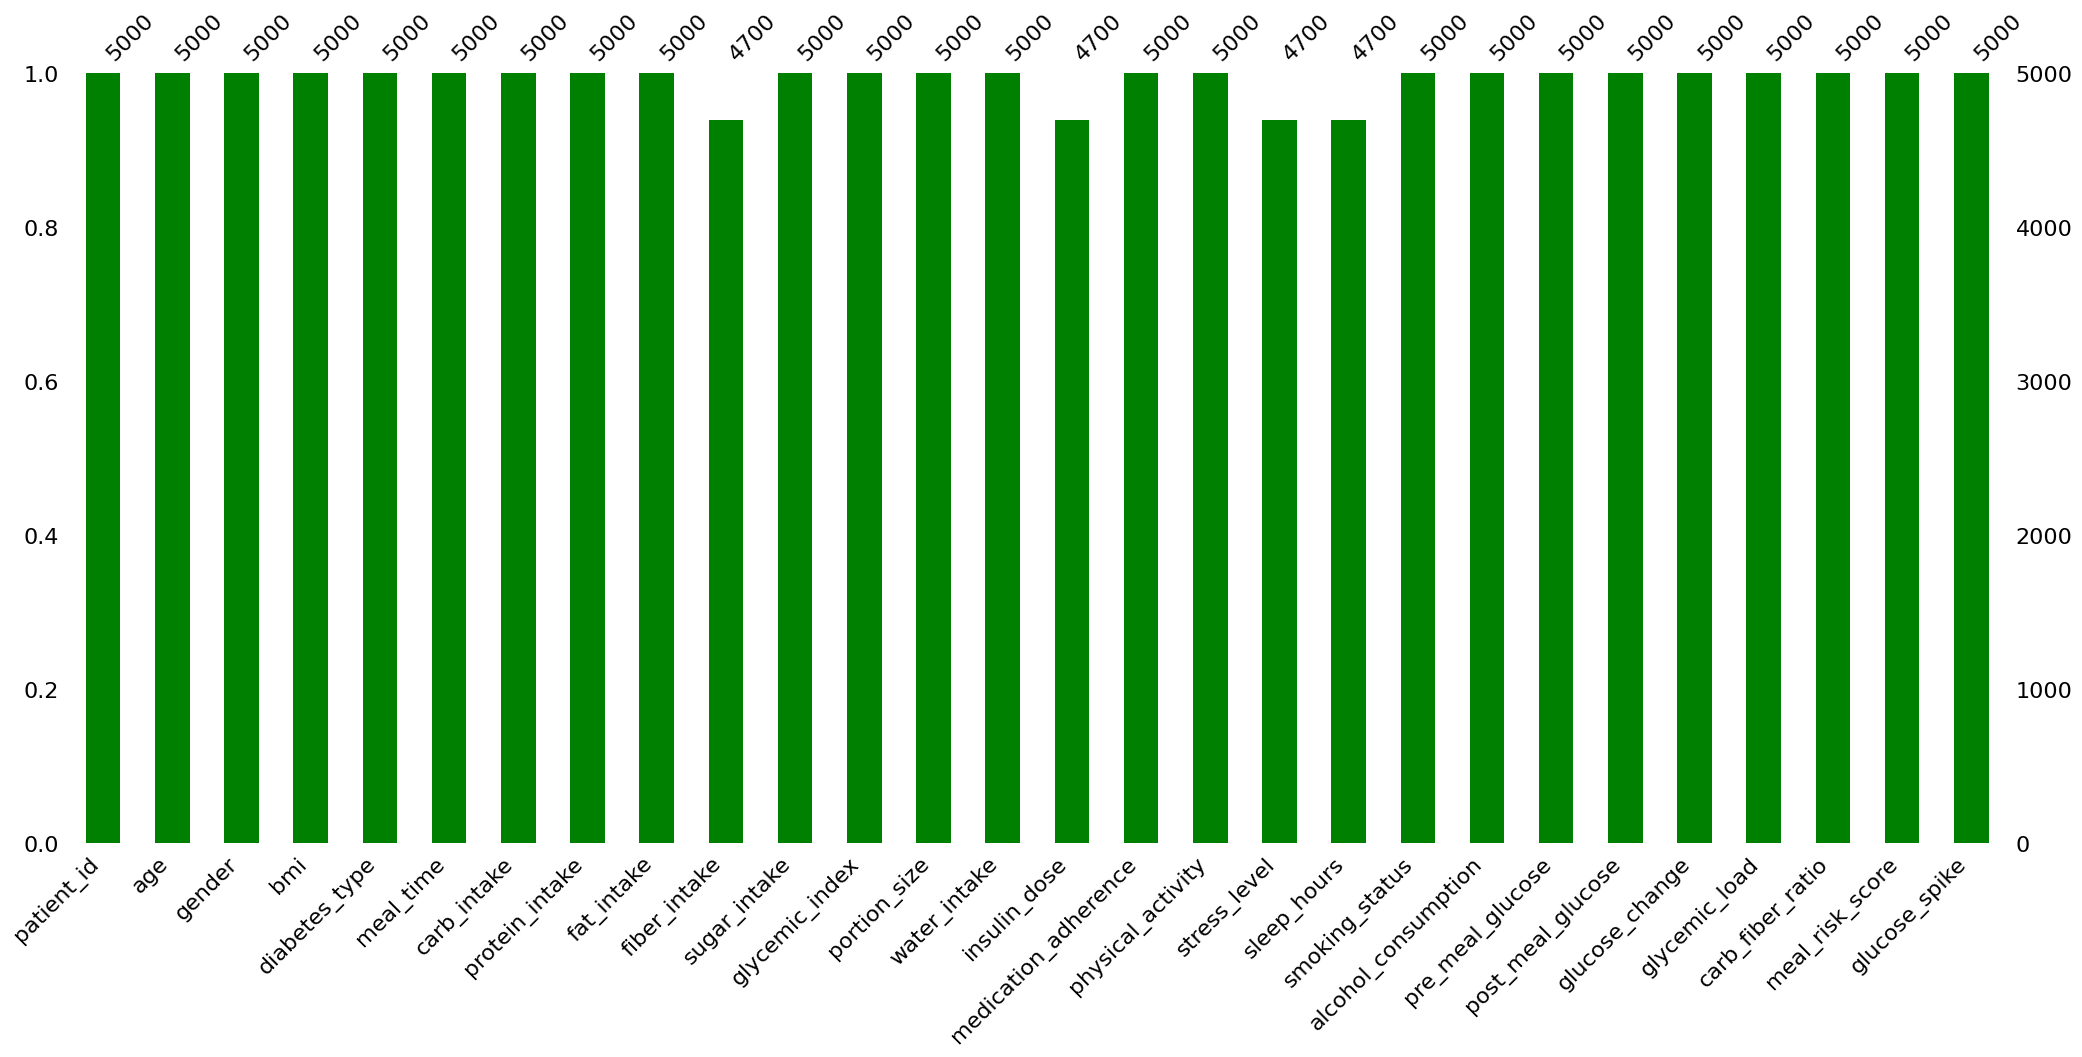

In [102]:
msno.bar(df, color="green");

In [103]:
# Handle the missing value in the column (fiber_intake) using group-based median imputation by meal_time)
median_fiber = df.groupby("meal_time")["fiber_intake"].agg(pd.Series.median)
median_fiber

meal_time
Breakfast    17.979295
Dinner       18.031759
Lunch        18.146588
Snack        17.809567
Name: fiber_intake, dtype: float64

In [104]:
df["fiber_intake"] = df["fiber_intake"].fillna(df["meal_time"].map(median_fiber))

In [105]:
# Handle the missing value in the column (Sleep Hours) using group-based median imputation by Gender)
median_sleep_hours = df.groupby("gender")["sleep_hours"].agg(pd.Series.median)
median_sleep_hours

gender
Female    6.504199
Male      6.509318
Name: sleep_hours, dtype: float64

In [106]:
df["sleep_hours"] = df["sleep_hours"].fillna(df["gender"].map(median_sleep_hours))

In [107]:
# Handle the missing value in the column (Stress Level) using group-based median imputation by Gender)
median_stress_level = df.groupby("gender")["stress_level"].agg(pd.Series.median)
median_stress_level

gender
Female    5.0
Male      5.0
Name: stress_level, dtype: float64

In [108]:
df["stress_level"] = df["stress_level"].fillna(df["gender"].map(median_sleep_hours))

In [109]:
# Handle the missing value in the column (insulin_dose), using group-based median imputation by diabetes_type
median_diabetes_type = df.groupby("diabetes_type")["insulin_dose"].agg(pd.Series.median)
median_diabetes_type

diabetes_type
Type 1    7.234708
Type 2    2.770875
Name: insulin_dose, dtype: float64

In [110]:
df["insulin_dose"] = df["insulin_dose"].fillna(df["diabetes_type"].map(median_diabetes_type))

In [111]:
# Check the missing value after imputation
df.isnull().sum()

patient_id              0
age                     0
gender                  0
bmi                     0
diabetes_type           0
meal_time               0
carb_intake             0
protein_intake          0
fat_intake              0
fiber_intake            0
sugar_intake            0
glycemic_index          0
portion_size            0
water_intake            0
insulin_dose            0
medication_adherence    0
physical_activity       0
stress_level            0
sleep_hours             0
smoking_status          0
alcohol_consumption     0
pre_meal_glucose        0
post_meal_glucose       0
glucose_change          0
glycemic_load           0
carb_fiber_ratio        0
meal_risk_score         0
glucose_spike           0
dtype: int64

     To preserve the dataset while maintaining realistic patient characteristics, group-based median imputation was applied. The median was chosen because of outliers, and grouping ensured that missing values found in the features (sleep_hours, fiber_intake, insulin_dose and stess_level) were replaced using values from similar patients rather than the overall dataset. This approach improved data quality, reduced bias, preserved important relationships between variables, and ensured that all records could be used for exploratory analysis and machine learning modeling.

#### Check the columns for inconsistencies

In [112]:
df["meal_time"].unique()

<StringArray>
['Snack', 'Breakfast', 'Dinner', 'Lunch']
Length: 4, dtype: str

In [113]:
df["glucose_spike"].unique()

array([1, 0])

In [114]:
df["alcohol_consumption"].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [115]:
df["stress_level"].unique()

array([ 9.        ,  1.        , 10.        ,  4.        ,  6.        ,
        2.        ,  5.        ,  3.        ,  7.        ,  8.        ,
        6.50419915,  6.50931794])

In [116]:
df["diabetes_type"].unique()

<StringArray>
['Type 2', 'Type 1']
Length: 2, dtype: str

In [117]:
df["gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [118]:
df["smoking_status"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

        No inconsistencies found 

##### Drop irrelevant and inaccurate columns

In [119]:
df = df.drop(["patient_id"], axis=1,)

##### Handle outliers

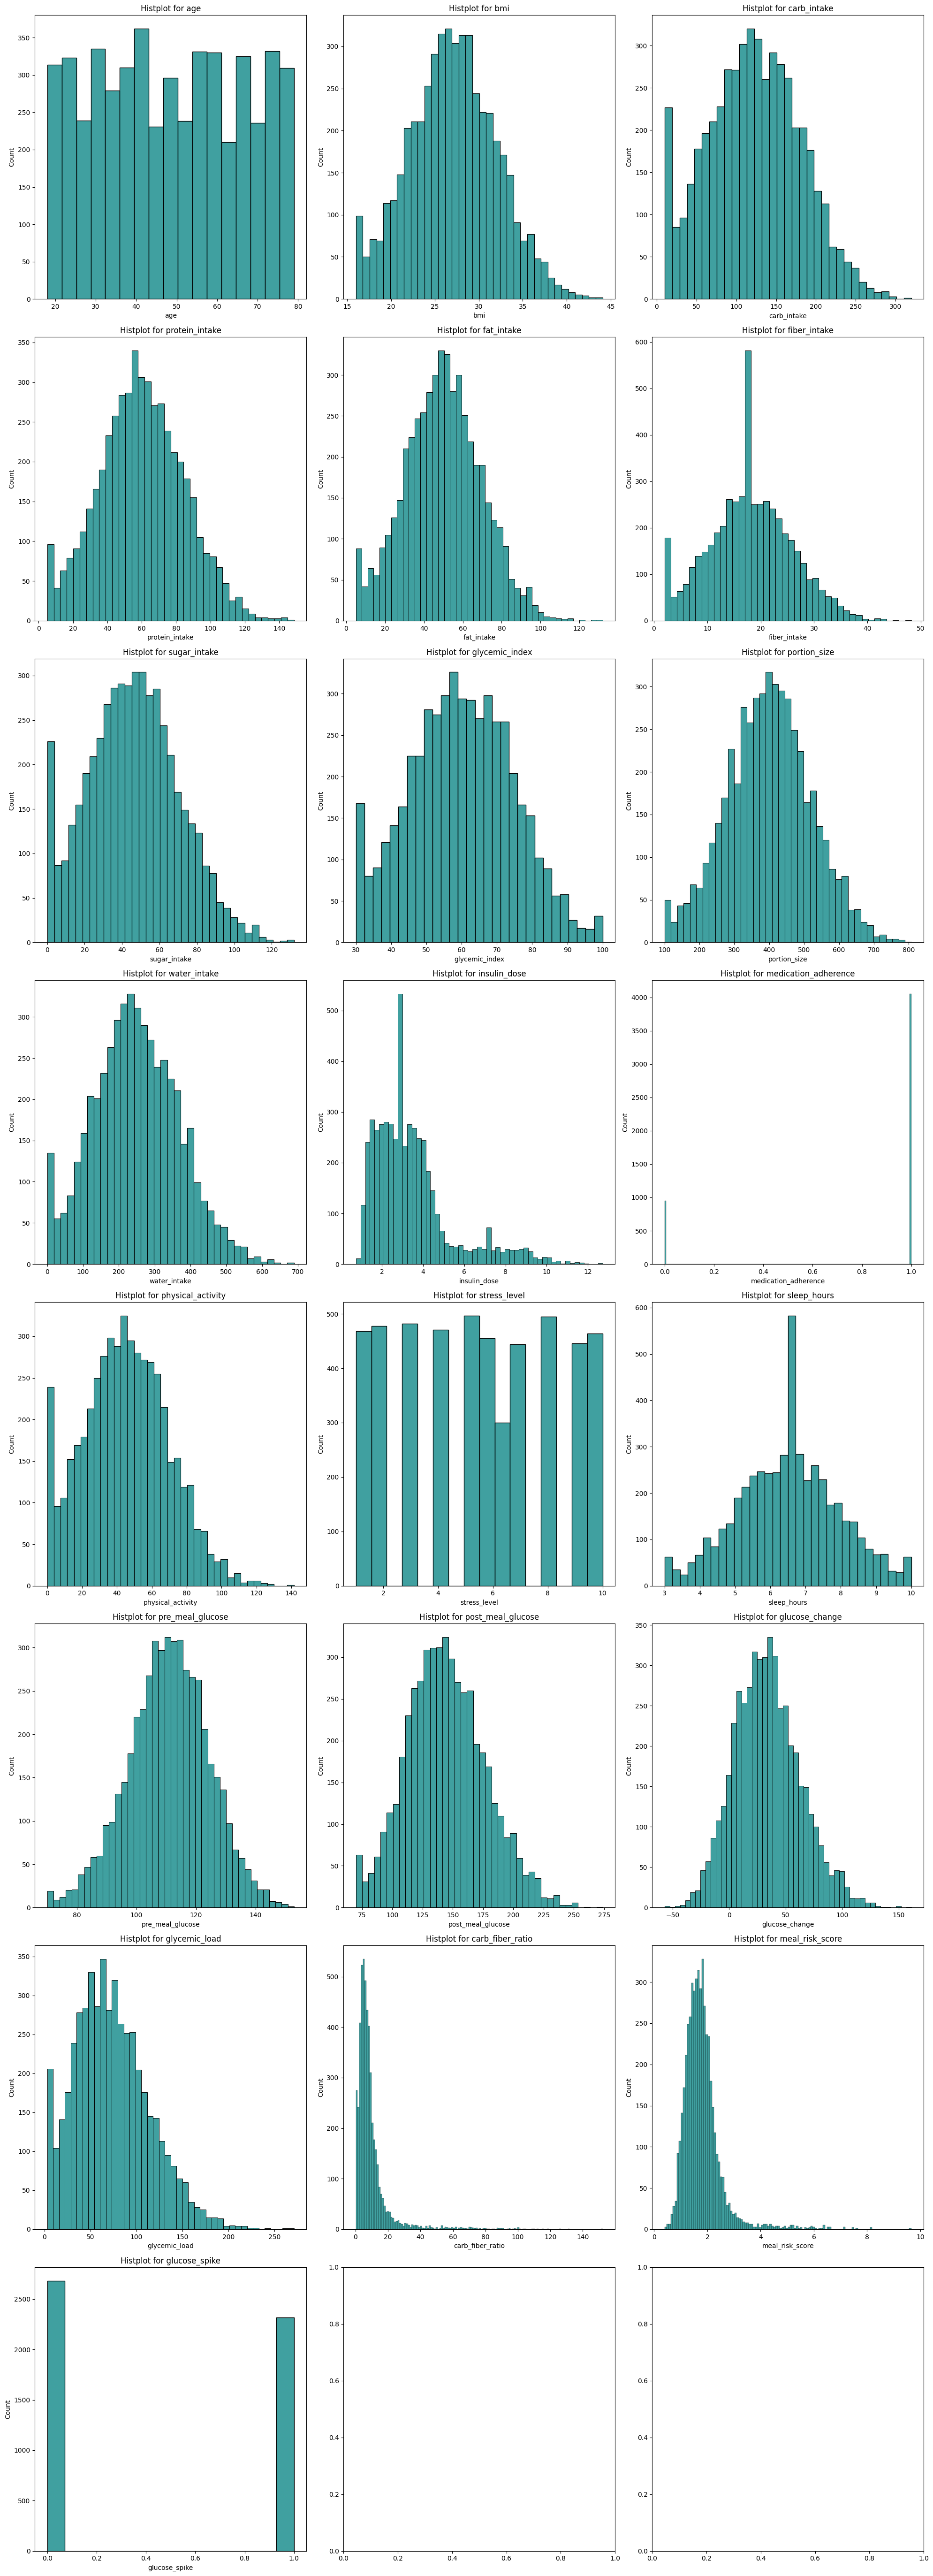

In [120]:
# Check for distribution of data in numerical columns
numerical_columns = df.select_dtypes(include="number")

fig, ax = plt.subplots(nrows=8, ncols=3, figsize=(20, 55))
ax=ax.flatten()

for idx, col in enumerate(numerical_columns):
    sns.histplot(df[col], color= "teal", ax=ax[idx])
    ax[idx].set_title(f"Histplot for {col}")

plt.tight_layout()
plt.show()

##### 0verview
- Distribution is fairly uniform across age groups, from 18 to 79 years.
- Most meals contain 80–180g carbs and some patients consume extremely high-carb meals.
- Most patients consume moderate protein amounts. No major outlier.
- Fat intake varies but with normal distribution and an average of 50g.
- Fiber intake has a peak around 18–20g, due to the group based median imputaion of the missing value.
- Some patients have meals that contain very high sugar levels.
- Most meals have moderate glycemic index values.
- Normal distribution of portion size.
- Most patients use low insulin doses.
- Many patients sleep less than the recommended 7–9 hours. The large central peak likely reflects median imputation.
- Strong outliers present in carb to fiber ratio.
- Most meals have low risk scores.

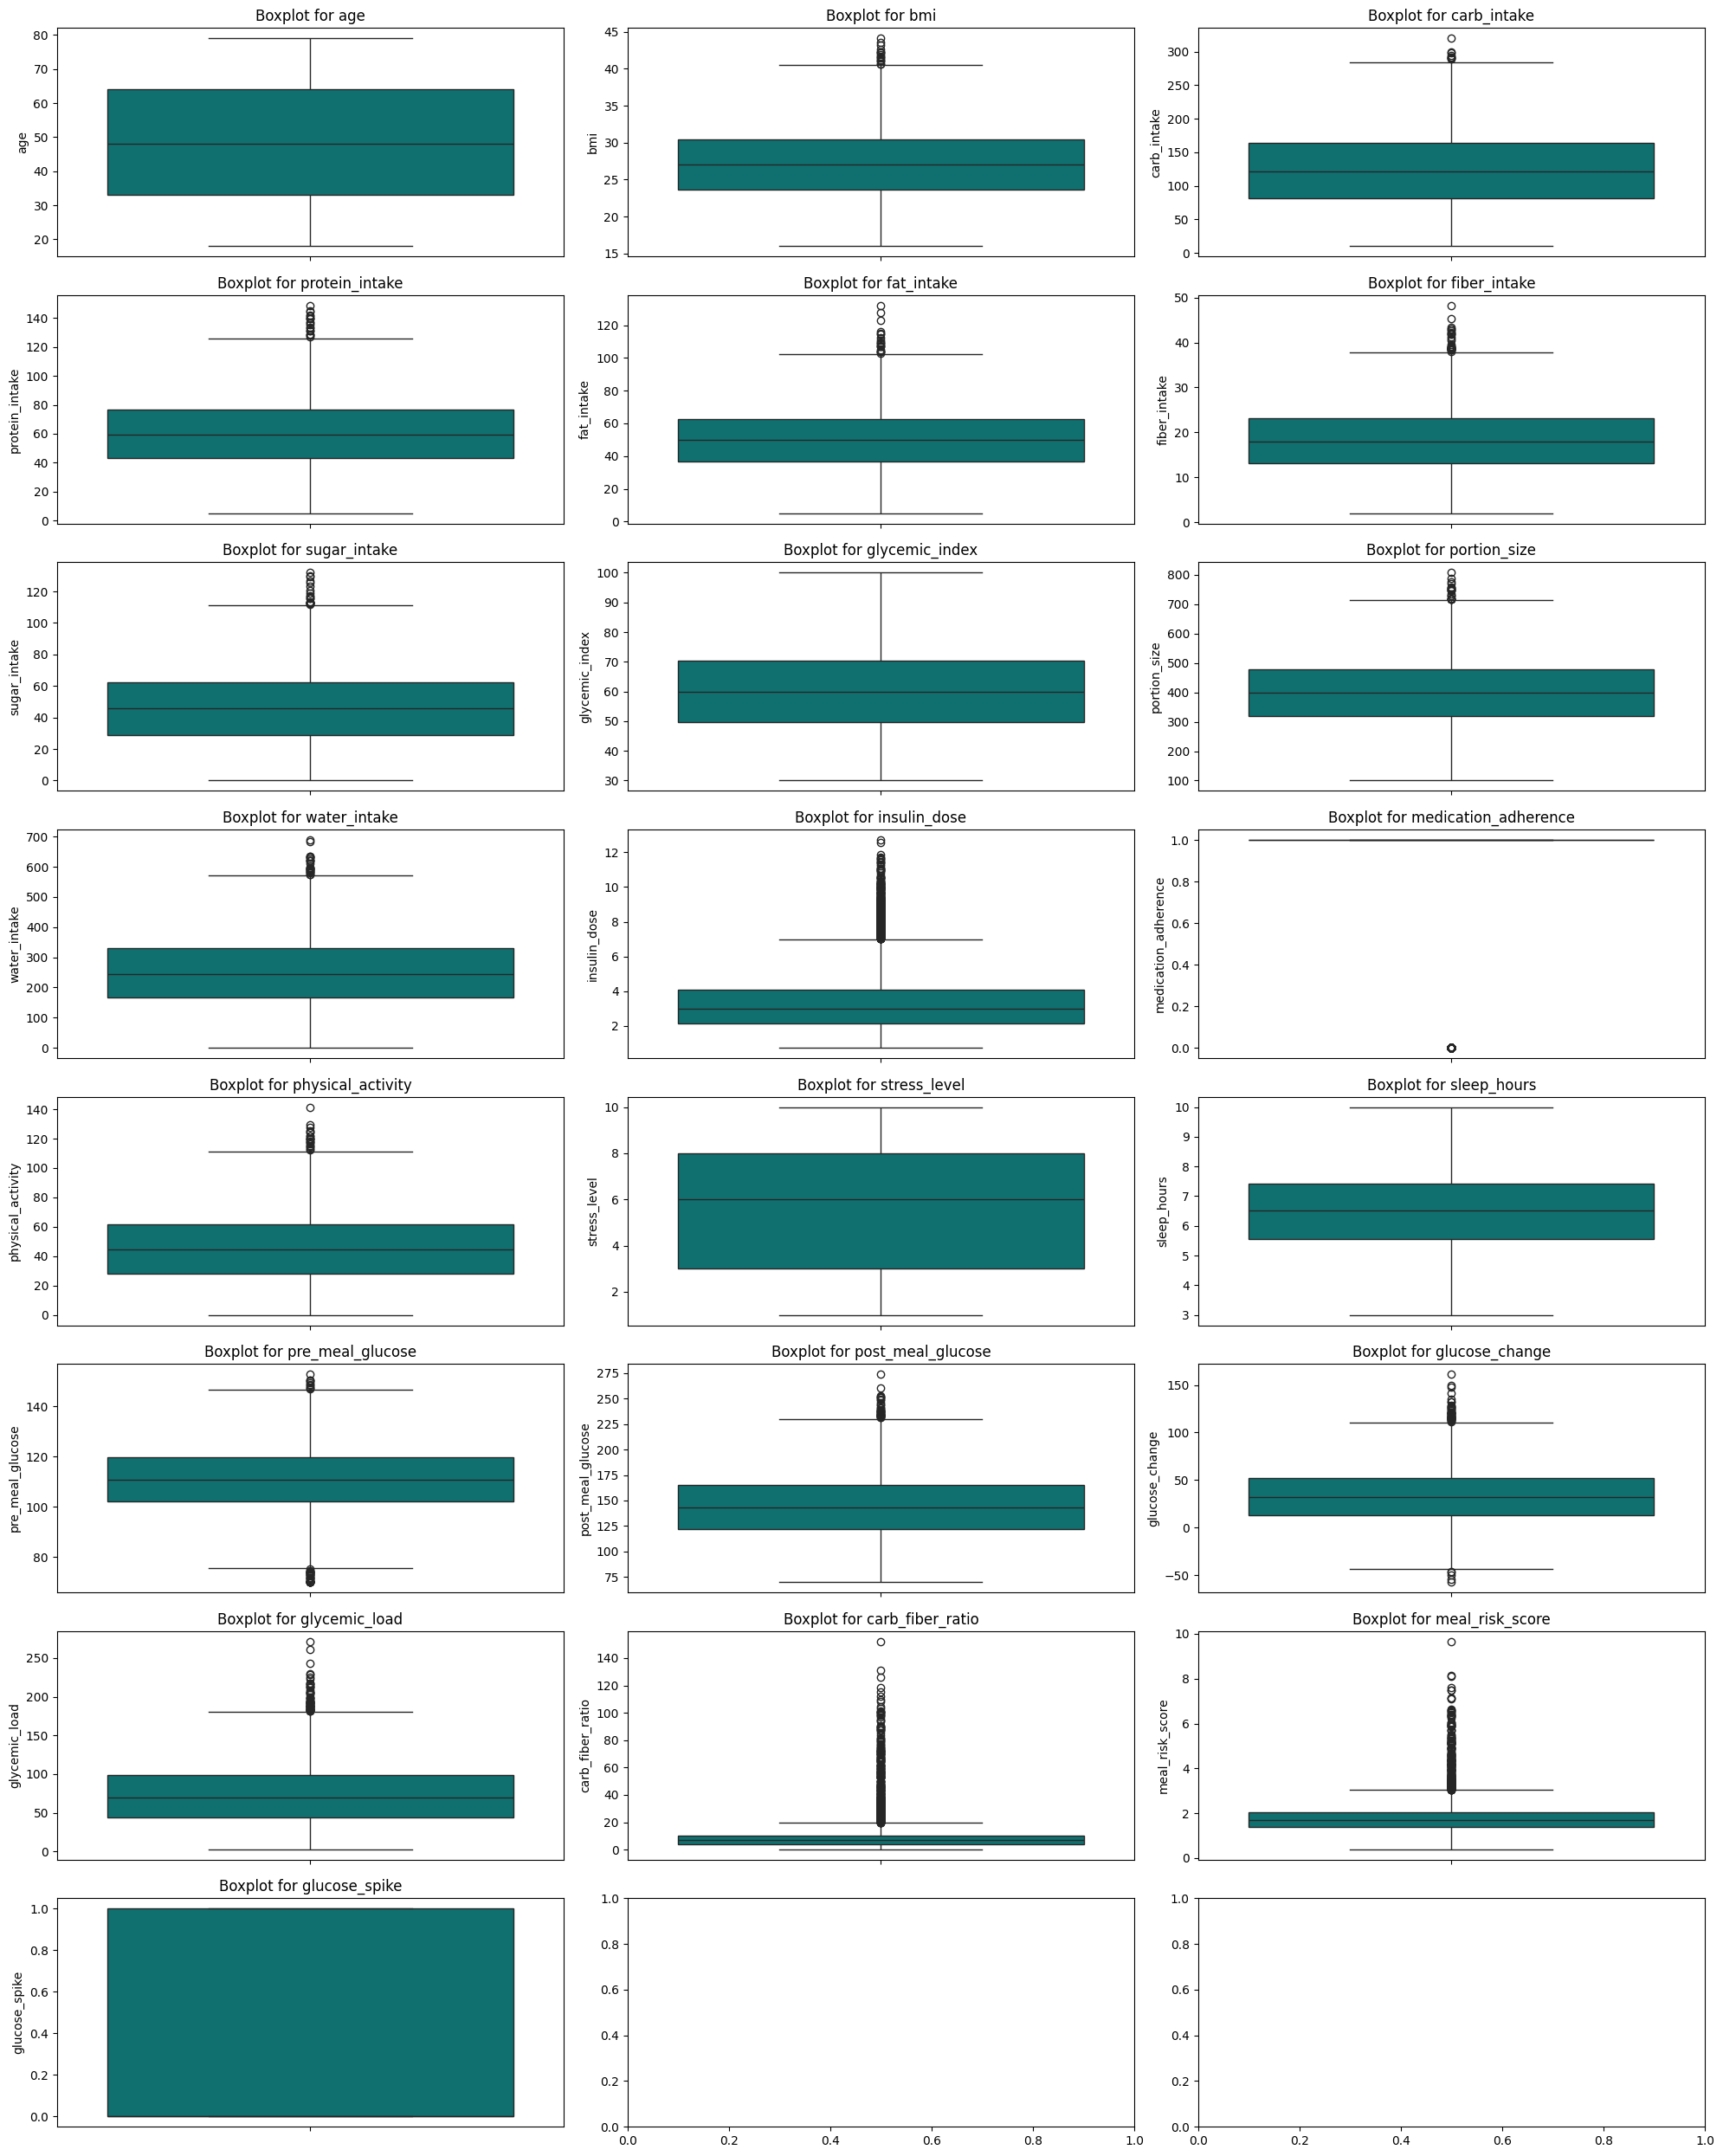

In [121]:
#Check for outliers
fig, axis = plt.subplots(nrows=8, ncols=3, figsize=(20, 25))
axis = axis.flatten()

for index, column_name in enumerate(numerical_columns):
    sns.boxplot(df[column_name], color="teal", ax=axis[index])
    axis[index].set_title(f"Boxplot for {column_name}")

plt.tight_layout()
plt.show()

##### Overview
- Features with Little or No Outlier (Age, Glycemic Index, Stress Level, Sleep Hours).
- Features with Strong Outliers (Insulin Dose, Glycemic Load, Carb-Fiber Ratio, Meal Risk Score, Glucose Change).

In [122]:
# Catergorical columns analysis
categorical_columns = df.select_dtypes(include=["object", "str"]).columns

In [123]:
len(categorical_columns)

5

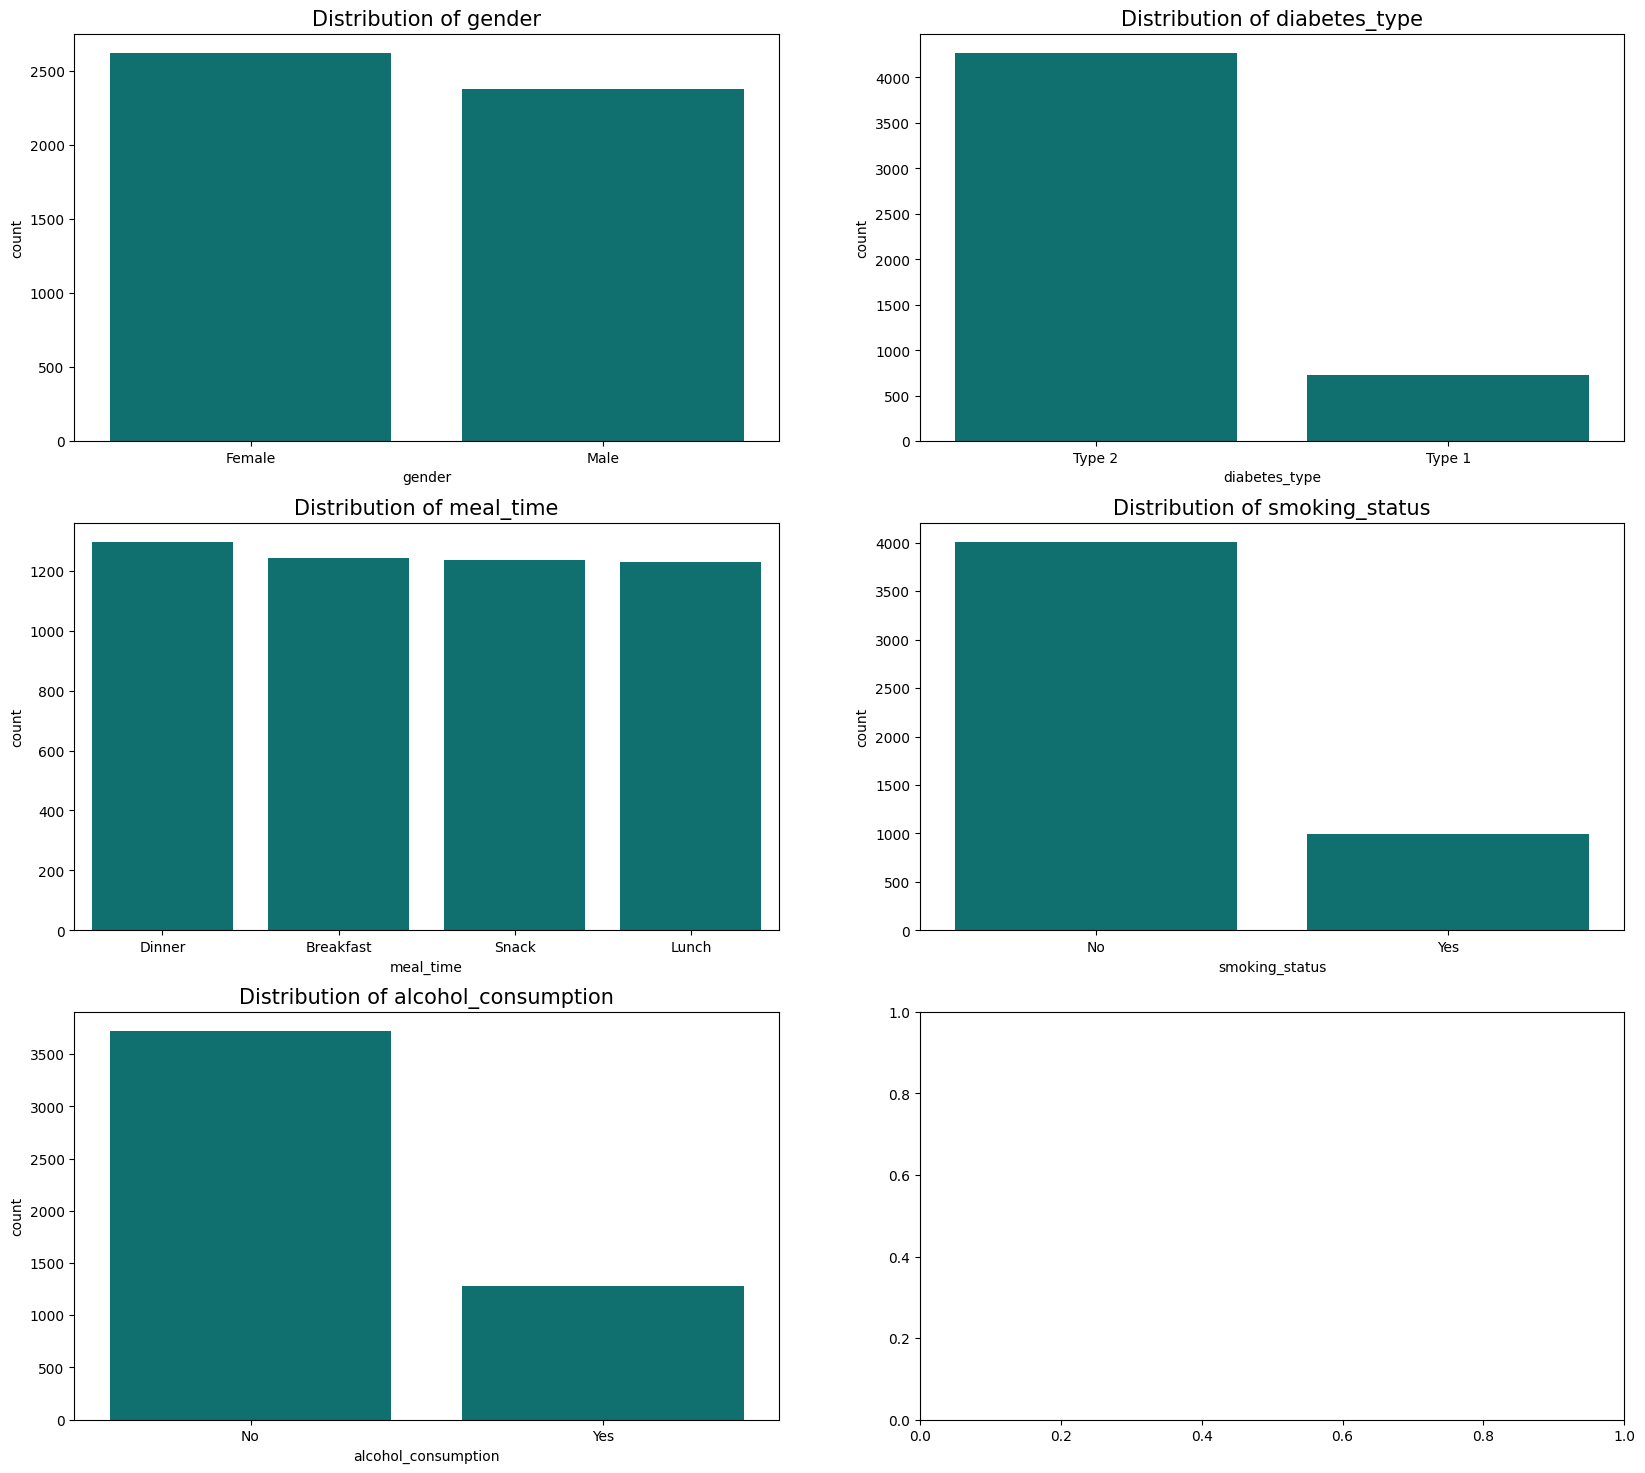

In [124]:
fig, ax = plt.subplots(nrows= 3, ncols=2, figsize=(20,18))
ax = ax.flatten()

for index, column_name in enumerate (categorical_columns):
    sns.countplot(x= df[column_name], ax=ax[index], color="teal", order= df[column_name].value_counts().index)
    ax[index].set_title(f"Distribution of {column_name}", fontsize=15)

plt.tight_layout
plt.show()

##### Overview
- There are slightly more females than males in this dataset.
- Most people have Type 2 diabetes, while Type 1 is much less common.
- People are fairly evenly distributed across meal times, with Dinner being the highest.
- Most people are non-smokers; only a smaller portion smoke.
- Most people do not consume alcohol, while fewer do.

#### Exploratory Data Analysis

##### Influence of diet on glucose spike.

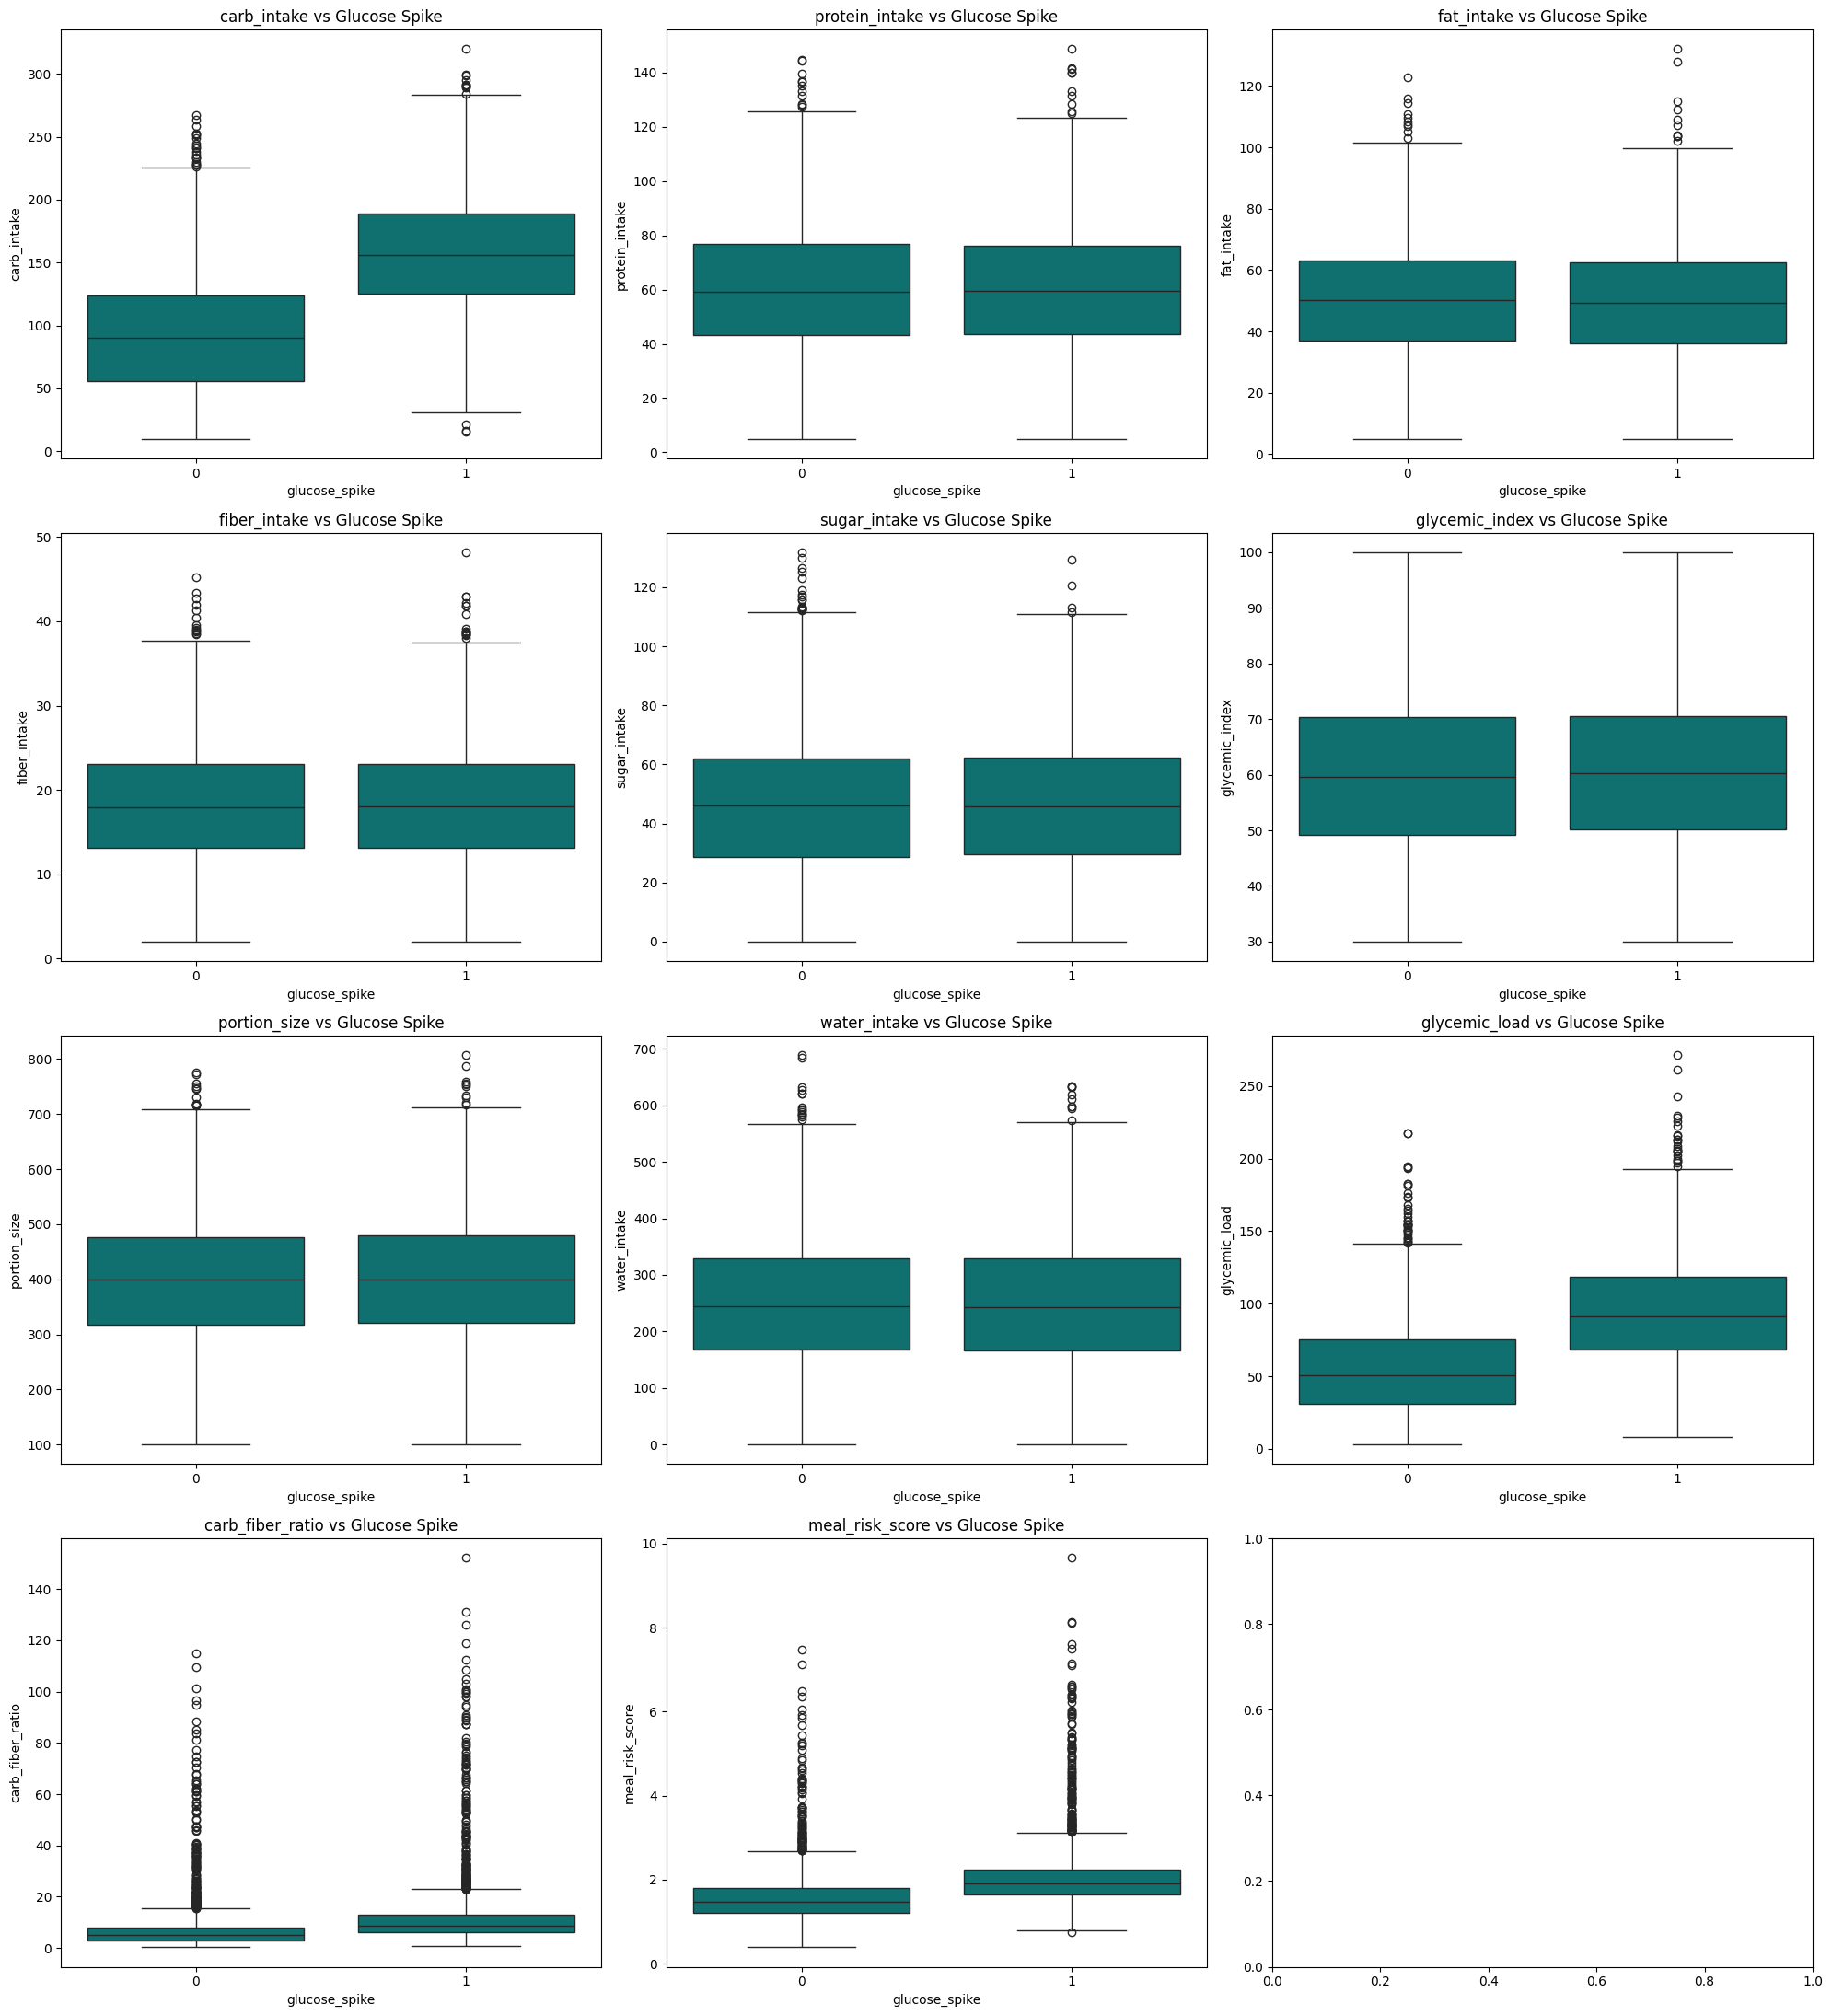

In [125]:
diet_features = ["carb_intake", "protein_intake", "fat_intake", "fiber_intake", "sugar_intake", "glycemic_index", "portion_size", "water_intake", 
                 "glycemic_load", "carb_fiber_ratio", "meal_risk_score"]

fig, ax = plt.subplots(nrows=4, ncols=3, figsize=(20, 22))
ax = ax.flatten()

for idx, col in enumerate(diet_features):
    sns.boxplot(data=df, x="glucose_spike", y=col, ax=ax[idx], color="teal")
    ax[idx].set_title(f"{col} vs Glucose Spike")

plt.tight_layout()
plt.show()

      The plots suggest that glucose spikes are primarily linked to high carbohydrate consumption, especially when those carbohydrates create a high glycemic load and are not balanced with enough fiber. Meal risk score is also a strong indicator of glucose spike. Protein, fat, water intake, and portion size show little evidence of a strong relationship with glucose spikes in this dataset. Sugar intake and Glycemic index are moderate indictators of of glucose spikes.

##### Effect of lifestyle on glucose spike

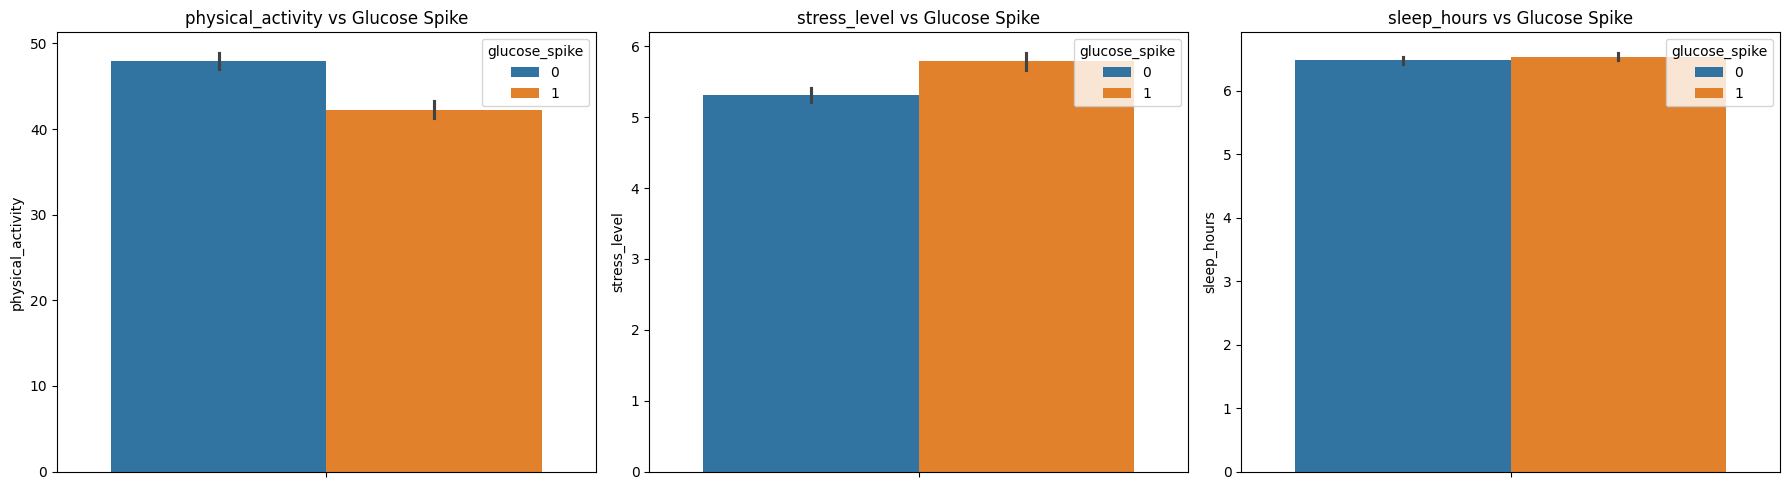

In [126]:
lifestyle_features = ["physical_activity", "stress_level", "sleep_hours"]
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(lifestyle_features):
    sns.barplot(data=df, hue="glucose_spike", y=col, ax=ax[idx])
    ax[idx].set_title((f"{col} vs Glucose Spike"))

plt.tight_layout()
plt.show()

     Lower physical activity and higher stress levels are associated with an increased likelihood of glucose spikes. While sleep duration showed little to no direct relationship with glucose spike.

##### Health Factors vs. Glucose Spike

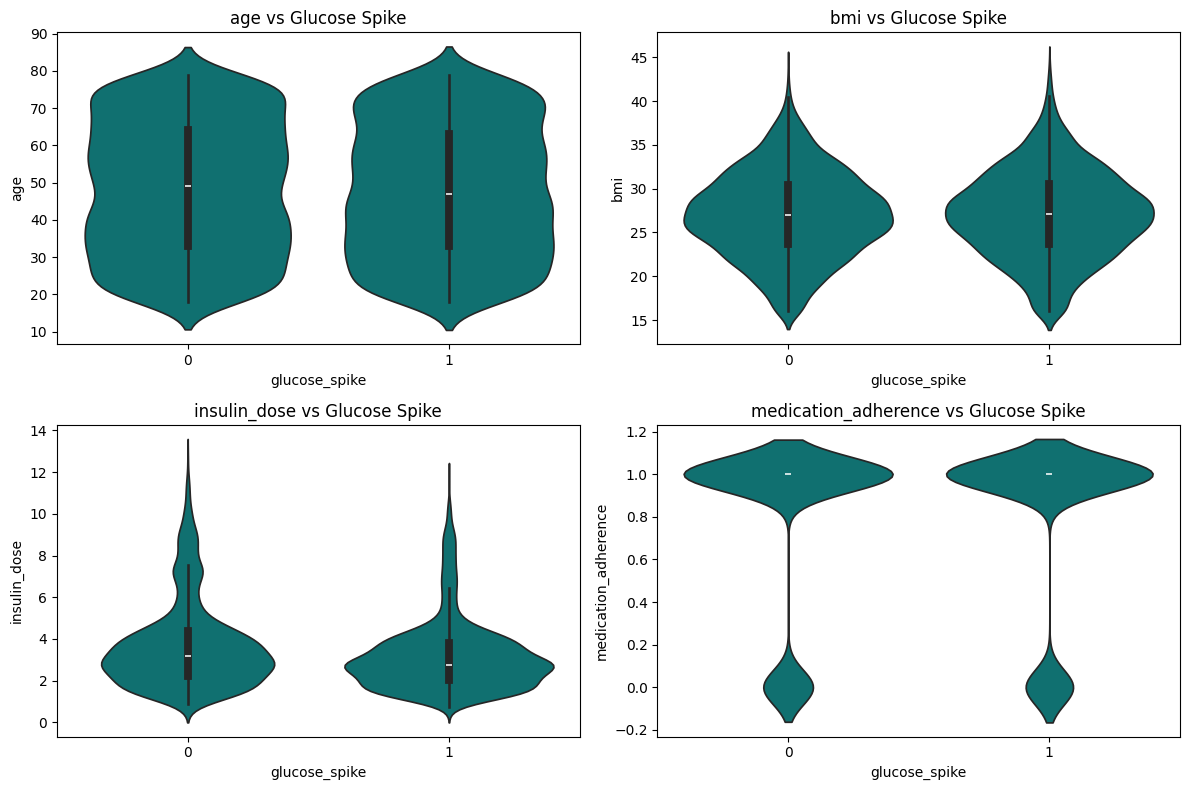

In [127]:
health_features = ["age", "bmi", "insulin_dose", "medication_adherence"]

fig, ax = plt.subplots(2,2, figsize=(12,8))
ax=ax.flatten()

for idx,col in enumerate(health_features):
    sns.violinplot(data=df, x="glucose_spike", y=col, ax=ax[idx], color="teal")
    ax[idx].set_title((f"{col} vs Glucose Spike"))

plt.tight_layout()
plt.show()

      Age does not seem to play a major role in causing a glucose spike here. People of all ages are equally distributed in both the spike and no-spike categories. Average BMI is about the same in both groups and no noticeable difference between spike and non-spike patients. on average, Non-spike group has a slightly higher insulin dose, while Spike group has a slightly lower insulin dose. A slightly higher insulin dose may help reduce the risk of glucose spikes. Most people in both groups take their medication perfectly. Medication adherence does not clearly explain glucose spikes..

##### Number of Glucose Spikes by Diabetes Type

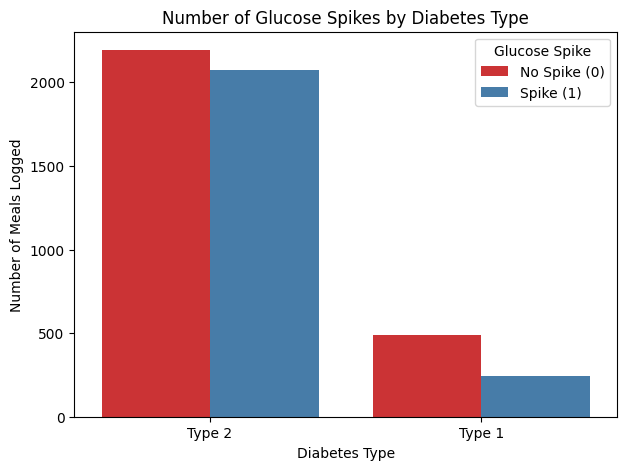

In [128]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='diabetes_type', hue='glucose_spike', palette='Set1')
plt.xlabel('Diabetes Type')
plt.ylabel('Number of Meals Logged')
plt.legend(title='Glucose Spike', labels=['No Spike (0)', 'Spike (1)'])
plt.title('Number of Glucose Spikes by Diabetes Type')
plt.show()

      Glucose spikes occur more among Type 2 diabetes patients than Type 1 patients. This suggests that diabetes type is an important factor in understanding glucose spike risk.

##### Meal Time and Glucose Spike Analysis

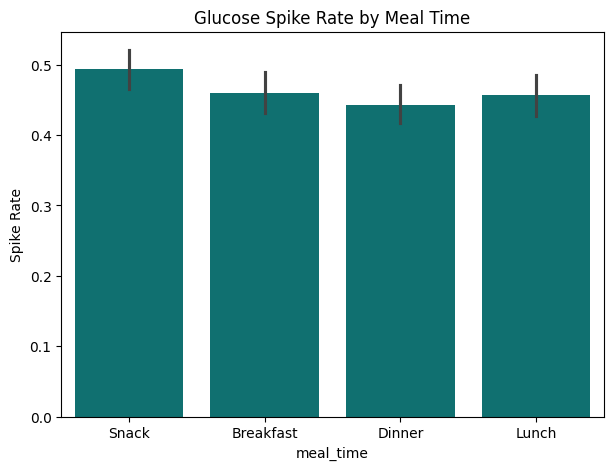

In [129]:
plt.figure(figsize=(7,5))

sns.barplot(data=df, x="meal_time", y="glucose_spike", color="teal")

plt.title("Glucose Spike Rate by Meal Time")
plt.ylabel("Spike Rate")

plt.show()

        Meal time does not make a massive difference and has a weak effect on glucose spikes. All meal types cause a glucose spike between 44% and 49% of the time. Snacks have the highest risk, while dinner has the lowest risk.

##### Glucose Dynamics Analysis

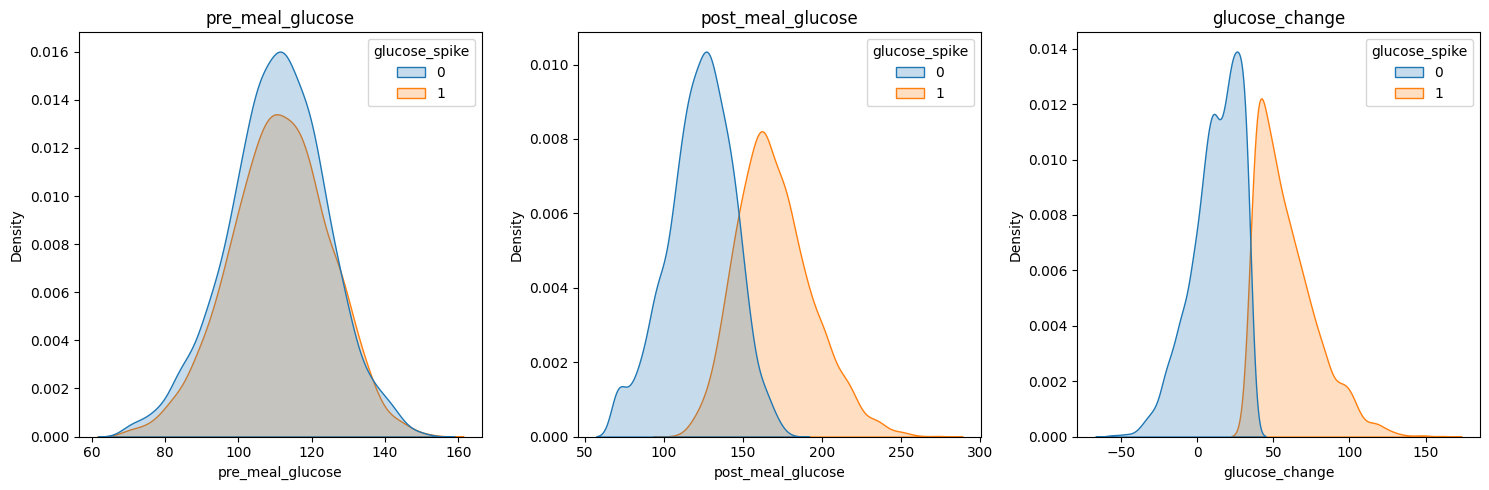

In [130]:
glucose_features = ["pre_meal_glucose", "post_meal_glucose", "glucose_change"]
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

for idx, col in enumerate(glucose_features):
    sns.kdeplot(data=df, x=col, hue="glucose_spike", fill=True, ax=ax[idx])
    ax[idx].set_title(col)

plt.tight_layout()
plt.show()

     Pre-meal glucose levels have little influence on glucose spike occurrence. In contrast, post-meal glucose levels and glucose change show a strong relationship with glucose spikes.

##### Glucose Spike Rate by Gender

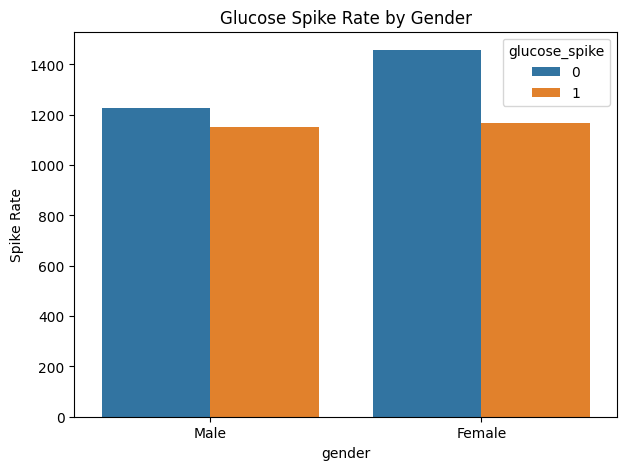

In [131]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x="gender", hue="glucose_spike")

plt.title("Glucose Spike Rate by Gender")
plt.ylabel("Spike Rate")

plt.show()

      Both males and females have very similar numbers of glucose spikes. Females have slightly more non-spike records, but the difference is small.Gender does not show a strong effect on glucose spike occurrence.

##### Glucose Spike Rateby Smoking and Alcohol Habits

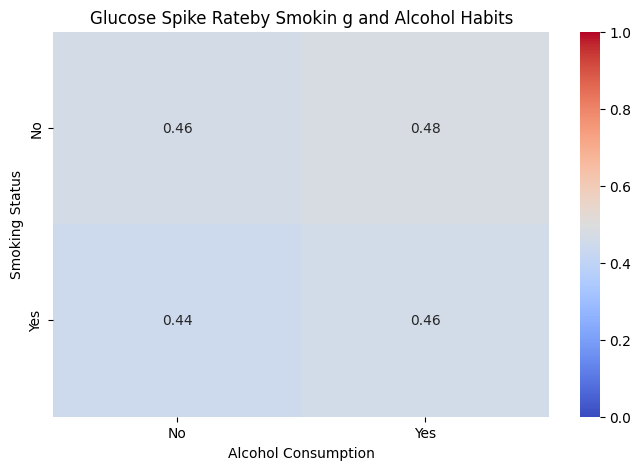

In [132]:
pivot_table = df.pivot_table(values='glucose_spike', index='smoking_status', columns='alcohol_consumption', aggfunc='mean')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)

plt.title('Glucose Spike Rateby Smokin g and Alcohol Habits')
plt.ylabel('Smoking Status')
plt.xlabel('Alcohol Consumption')
plt.show()

     The analysis indicates that smoking and alcohol consumption have only a minor relationship with glucose spikes. All groups show similar spike rates ranging from 44% to 48%, suggesting that these lifestyle habits are weak predictors of glucose spike.

##### Correlation and Relationship of the features

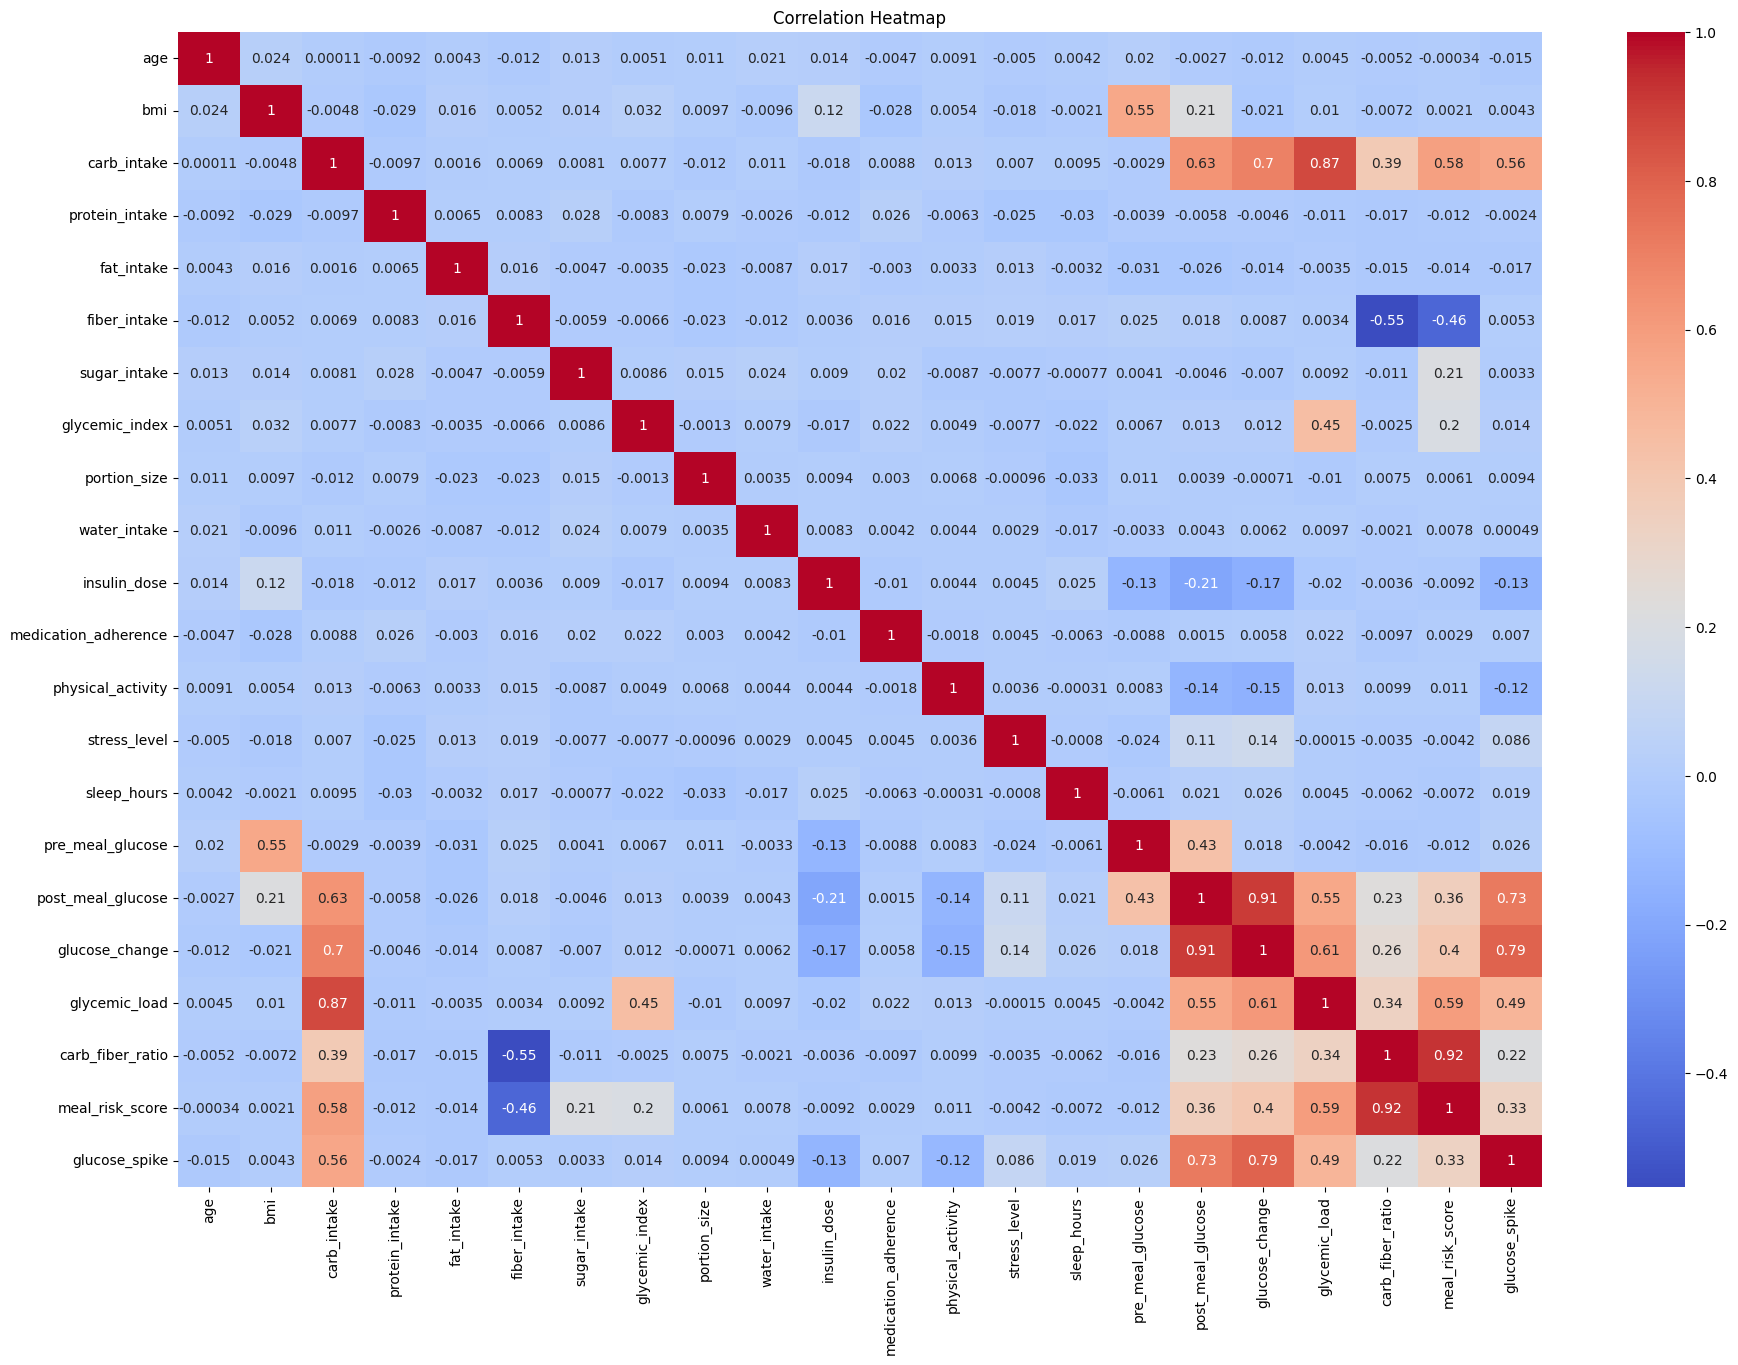

In [133]:
plt.figure(figsize=(22,15))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

      The analysis shows that glucose spikes are mainly driven by dietary and glucose-related factors. Higher carbohydrate intake, glycemic load, post-meal glucose, and glucose change are the strongest predictors of spikes. Physical activity and insulin dose act as protective factors, while age, BMI, sleep, smoking, and alcohol consumption show little direct impact on glucose spike occurrence.

#### Feature Engineering

##### Remove Features

In [134]:
df.drop(columns=["post_meal_glucose", "glucose_change"],inplace=True)

     Post_meal_glucose and glucose_change were removed bacause glucose spikes are determined after the meal. The objective is to predict a spike before it happens, these features would give the answer away.

##### Create new features

BMI Catergory

In [135]:
def bmi_category(bmi):
    if bmi < 18.5: return "Underweight"
    elif bmi < 25: return "Normal"
    elif bmi < 30: return "Overweight"
    else: return "Obese"

df["bmi_category"] = df["bmi"].apply(bmi_category)

In [136]:
df["bmi_category"].value_counts()

bmi_category
Overweight     1929
Normal         1472
Obese          1368
Underweight     231
Name: count, dtype: int64

Age Group

In [137]:
def age_group(age):
    if age <= 30: return "Young Adult"
    elif age <= 45: return "Adult"
    elif age <= 60: return "Middle Age"
    else: return "Old Age"

df["age_group"] = df["age"].apply(age_group)

In [138]:
df["age_group"].value_counts()

age_group
Old Age        1495
Adult          1255
Middle Age     1196
Young Adult    1054
Name: count, dtype: int64

Percentage of Glucose Spikes by Age Group and BMI Category

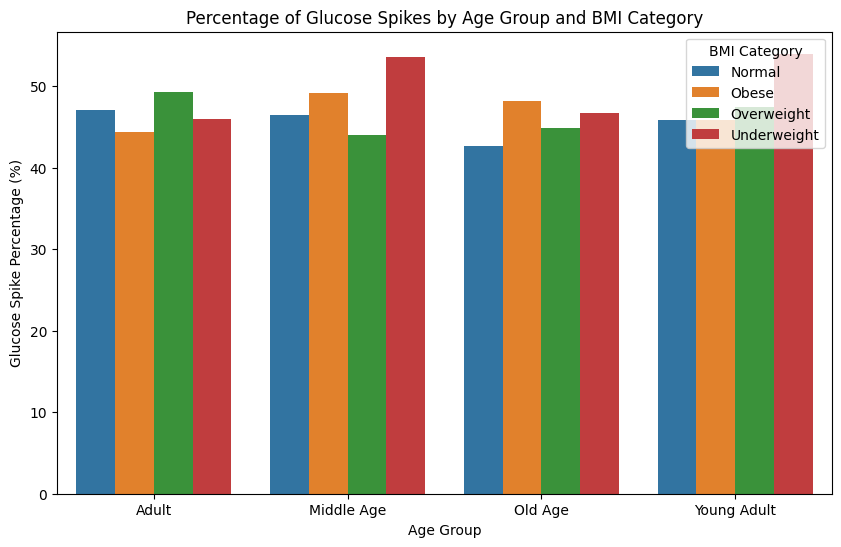

In [139]:
glucose_percent = (df.groupby(["age_group", "bmi_category"])["glucose_spike"].mean().reset_index())
glucose_percent["glucose_spike"] = glucose_percent["glucose_spike"] * 100

plt.figure(figsize=(10, 6))
sns.barplot(data=glucose_percent, x="age_group", y="glucose_spike", hue="bmi_category")

plt.title("Percentage of Glucose Spikes by Age Group and BMI Category")
plt.xlabel("Age Group")
plt.ylabel("Glucose Spike Percentage (%)")
plt.legend(title="BMI Category")
plt.show()

      Among young adults and middle age, underweight individuals experienced more glucose spikes than other BMI groups. In older adults, obese individuals experienceD glucose spikes than other BMI categories. Among adults, overweight individuals showed a slightly higher glucose spike percentage than other BMI groups.

Fiber Protection Score

In [140]:
df["fiber_protection"] = (df["fiber_intake"] / df["carb_intake"])

       This feature measures how much fiber is available to slow down the effect of carbohydrates. The analysis shows high carb intake leads to more spikes while higher fiber leads to lower meal risk.

Activity-Carb Ratio

In [141]:
df["activity_carb_ratio"] = (df["physical_activity"] / df["carb_intake"])

      The Activity-Carb Ratio measures how much physical activity a person performs to burn the carbohydrates they consume. The analysis shows physical activity reduces spikes while carbs increase spikes.

Insulin Efficiency

In [142]:
df["insulin_efficiency"] = (df["insulin_dose"] / df["carb_intake"])

     This feature finds out if the insulin dose is sufficient for the amount of carbohydrates consumed. The analysis showed Carb Intake increases glucose spike risk while Insulin Dose reduces glucose spike risk.

Glycemic Index and Portion Size Interaction

df["gi_portion_interaction"] = (df["glycemic_index"] * df["portion_size"])

          This feature measures how much glucose impact a meal may have based on both food quality and meal size.

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   gender                5000 non-null   str    
 2   bmi                   5000 non-null   float64
 3   diabetes_type         5000 non-null   str    
 4   meal_time             5000 non-null   str    
 5   carb_intake           5000 non-null   float64
 6   protein_intake        5000 non-null   float64
 7   fat_intake            5000 non-null   float64
 8   fiber_intake          5000 non-null   float64
 9   sugar_intake          5000 non-null   float64
 10  glycemic_index        5000 non-null   float64
 11  portion_size          5000 non-null   float64
 12  water_intake          5000 non-null   float64
 13  insulin_dose          5000 non-null   float64
 14  medication_adherence  5000 non-null   int64  
 15  physical_activity     5000 non-n

##### Confirm class balance of target variable (glucose_spike)

In [144]:
df["glucose_spike"].value_counts(normalize=True)*100

glucose_spike
0    53.66
1    46.34
Name: proportion, dtype: float64

     The target variable is fairly balanced, with similar numbers of glucose spike and non-glucose spike cases. Therefore, no additional balancing techniques are required before model training.

##### Drop redundant categorical bins before model training

In [145]:
df = df.drop(["age_group", "bmi_category"], axis=1)

##### Check for outliers

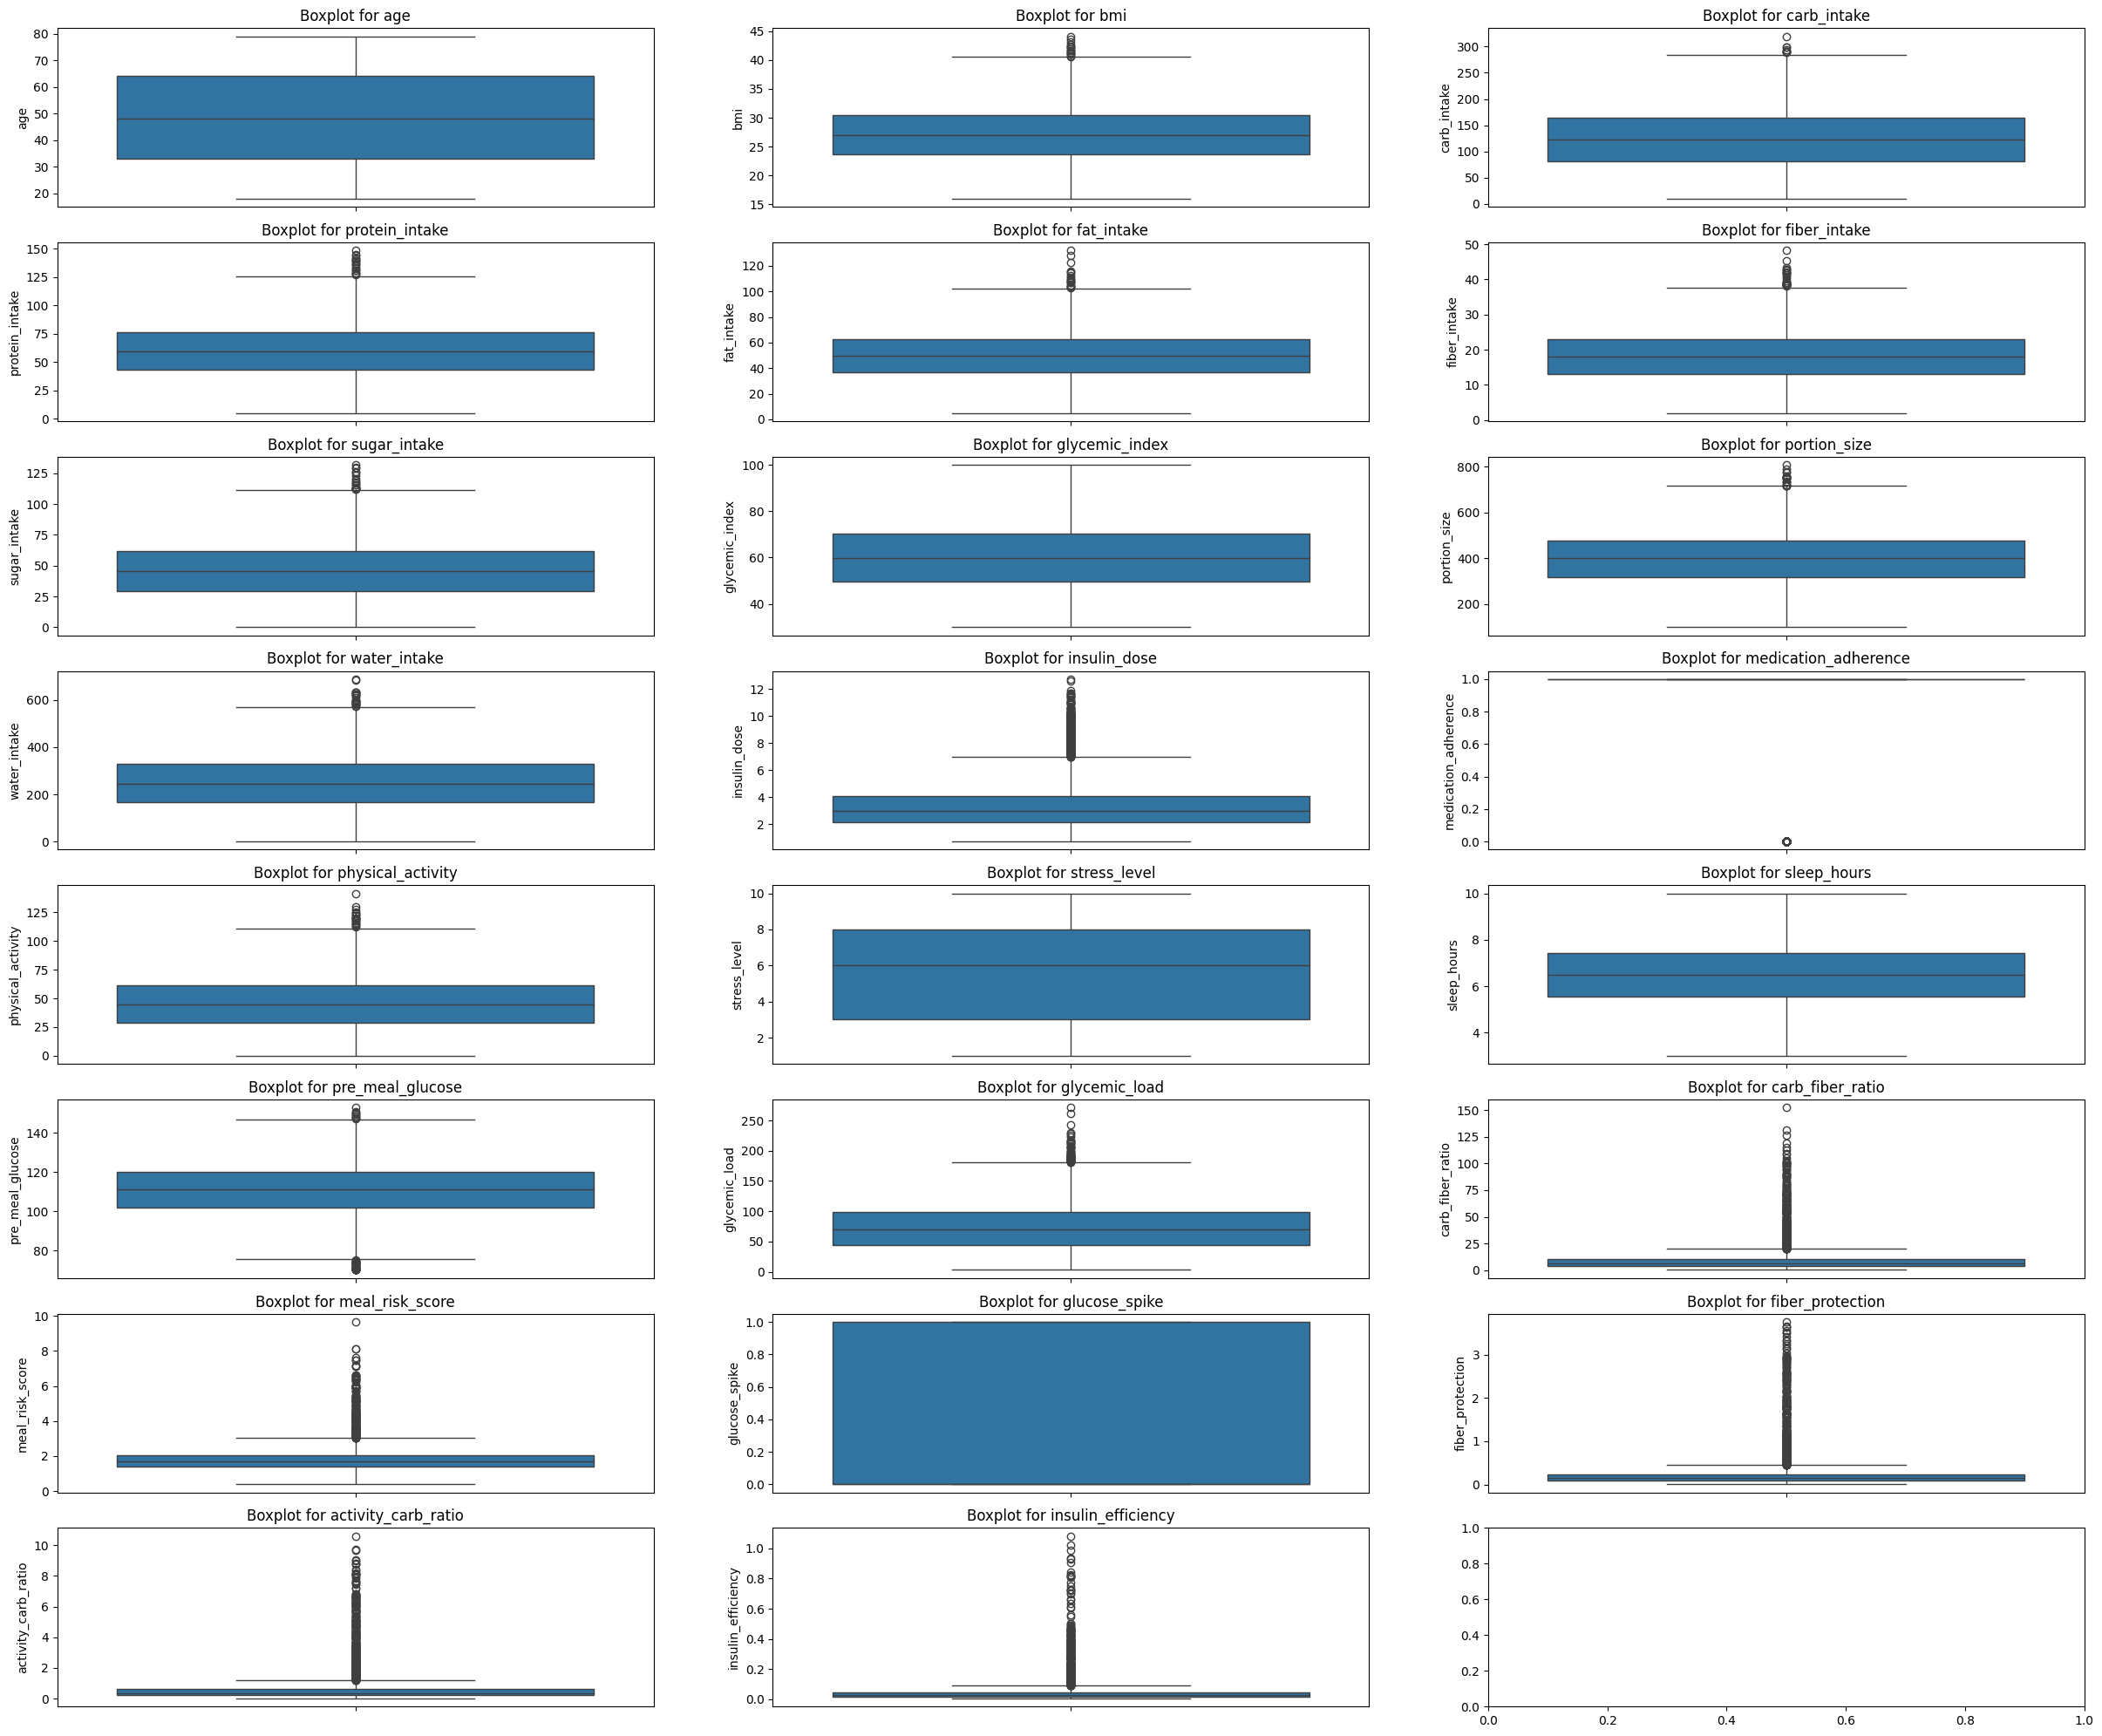

In [146]:
numerical_columns = df.select_dtypes(include= "number").columns

fig, ax = plt.subplots(nrows=8, ncols=3, figsize=(30, 25))
ax=ax.flatten()
for idx, col in enumerate(numerical_columns):
    sns.boxplot(df[col], ax=ax[idx])
    ax[idx].set_title(f"Boxplot for {col}")
plt.show()

     These features contain many extreme values: Insulin Dose, Glycemic Load, Carb-Fiber Ratio, Meal Risk Score, Fiber Protection, Activity-Carb Ratio and Insulin Efficiency

In [147]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   5000 non-null   int64  
 1   gender                5000 non-null   str    
 2   bmi                   5000 non-null   float64
 3   diabetes_type         5000 non-null   str    
 4   meal_time             5000 non-null   str    
 5   carb_intake           5000 non-null   float64
 6   protein_intake        5000 non-null   float64
 7   fat_intake            5000 non-null   float64
 8   fiber_intake          5000 non-null   float64
 9   sugar_intake          5000 non-null   float64
 10  glycemic_index        5000 non-null   float64
 11  portion_size          5000 non-null   float64
 12  water_intake          5000 non-null   float64
 13  insulin_dose          5000 non-null   float64
 14  medication_adherence  5000 non-null   int64  
 15  physical_activity     5000 non-n

##### Encode Categorical Variables

In [148]:
df_encoded = pd.get_dummies(df, columns=["gender", "diabetes_type", "meal_time", "smoking_status", "alcohol_consumption"], drop_first=True, dtype=int)

In [149]:
df_encoded.head()

,age,bmi,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,glycemic_index,portion_size,water_intake,...,fiber_protection,activity_carb_ratio,insulin_efficiency,gender_Male,diabetes_type_Type 2,meal_time_Dinner,meal_time_Lunch,meal_time_Snack,smoking_status_Yes,alcohol_consumption_Yes
0,63,25.318753,206.078625,96.988928,81.332092,19.881550,27.005984,67.508785,100.000000,241.797963,...,0.096476,0.152292,0.011608,1,1,0,0,1,1,0
1,43,29.887205,110.277131,41.988332,65.323781,9.660801,74.298628,72.596360,482.378834,229.778879,...,0.087605,0.436291,0.052056,0,0,0,0,1,0,0
2,65,21.831540,88.692079,74.612428,26.828247,26.701083,48.146920,52.777497,564.170251,203.040939,...,0.301054,0.371406,0.102484,0,0,0,0,0,0,0
3,56,26.610861,168.193534,70.944312,58.451133,23.006694,56.527922,76.054964,400.899454,370.953210,...,0.136787,0.180339,0.013883,1,1,1,0,0,0,0
4,58,26.649132,93.580856,74.851625,14.576802,19.789018,0.000000,62.084038,521.332119,587.526798,...,0.211464,0.524154,0.027161,1,1,1,0,0,1,0


##### Splitting the dataset into training and test sets¶

In [150]:
%pip install scikit-learn
from sklearn.model_selection import train_test_split

X = df_encoded.drop("glucose_spike", axis=1)
y = df_encoded["glucose_spike"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Note: you may need to restart the kernel to use updated packages.


In [151]:
X_train.dtypes

age                          int64
bmi                        float64
carb_intake                float64
protein_intake             float64
fat_intake                 float64
fiber_intake               float64
sugar_intake               float64
glycemic_index             float64
portion_size               float64
water_intake               float64
insulin_dose               float64
medication_adherence         int64
physical_activity          float64
stress_level               float64
sleep_hours                float64
pre_meal_glucose           float64
glycemic_load              float64
carb_fiber_ratio           float64
meal_risk_score            float64
fiber_protection           float64
activity_carb_ratio        float64
insulin_efficiency         float64
gender_Male                  int64
diabetes_type_Type 2         int64
meal_time_Dinner             int64
meal_time_Lunch              int64
meal_time_Snack              int64
smoking_status_Yes           int64
alcohol_consumption_

##### Scale Numerical Features

In [152]:
num_cols = ['age','bmi', 'carb_intake', 'protein_intake', 'fat_intake', 'fiber_intake', 'sugar_intake', 'glycemic_index', 'portion_size', 
            'water_intake', 'insulin_dose', 'physical_activity', 'stress_level', 'sleep_hours', 'pre_meal_glucose', 'glycemic_load',
            'carb_fiber_ratio', 'meal_risk_score', 'fiber_protection', 'activity_carb_ratio', 'insulin_efficiency']

In [153]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

##### Machine Learning

Train and evaluate baseline models

In [154]:
# Import the models and metrics

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score


In [155]:
# Define the models

models = {
    "Logistic Regression": LogisticRegression(random_state= 42),
    "Random Forest": RandomForestClassifier(random_state= 42)
}


--- Logistic Regression Results ---
Accuracy: 0.7680
Precision: 0.7381
Recall: 0.7732
F1 Score: 0.7553
ROC-AUC: 0.8579

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       537
           1       0.74      0.77      0.76       463

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



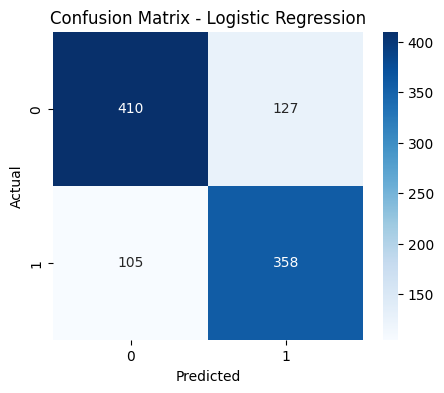

--------------------------------------------------

--- Random Forest Results ---
Accuracy: 0.7580
Precision: 0.7278
Recall: 0.7624
F1 Score: 0.7447
ROC-AUC: 0.8419

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       537
           1       0.73      0.76      0.74       463

    accuracy                           0.76      1000
   macro avg       0.76      0.76      0.76      1000
weighted avg       0.76      0.76      0.76      1000



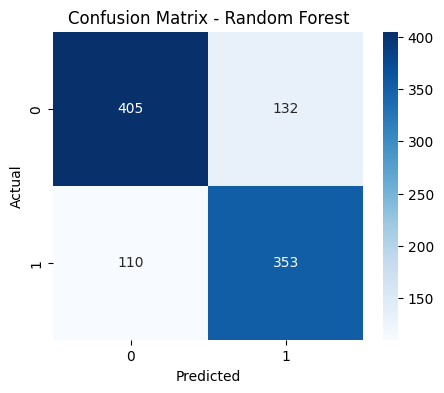

--------------------------------------------------


In [156]:
results = {}

for model_name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Evaluate Metrics
    Accuracy = accuracy_score(y_test, y_pred)
    Precision = precision_score(y_test, y_pred)
    Recall = recall_score(y_test, y_pred)
    F1_Score = f1_score(y_test, y_pred)
    ROC_AUC = roc_auc_score(y_test, y_prob)
    Report = classification_report(y_test, y_pred)
    Matrix = confusion_matrix(y_test, y_pred)

    # Store results
    results[model_name] = {
        'accuracy': Accuracy,
        'precision': Precision,
        'recall': Recall,
        'f1_score': F1_Score,
        'roc_auc': ROC_AUC,
        'report': Report,
        'matrix': Matrix
    }

# Display Results
for model_name, data in results.items():

    print(f"\n--- {model_name} Results ---")
    print(f"Accuracy: {data['accuracy']:.4f}")
    print(f"Precision: {data['precision']:.4f}")
    print(f"Recall: {data['recall']:.4f}")
    print(f"F1 Score: {data['f1_score']:.4f}")
    print(f"ROC-AUC: {data['roc_auc']:.4f}")

    print("\nClassification Report:")
    print(data['report'])

# Confustion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(data['matrix'], annot=True, fmt='d',cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    print("-" * 50)

      The Logistic Regression model achieved 76.8% accuracy (predicted 768 out of 1,000 meals correctly), 73.8% precision (when it predicts a spike, it is correct about 74% of the time), 77.3% recall (successfully detected 77% of actual glucose spikes), 75.5% F1-score (good balance between precision and recall), and 85.8% ROC-AUC (Strong ability to distinguish between spike and non-spike meals). It correctly identified 410 non-spike meals (True Negatives) and 358 spike meals (True Positives) while making 127 false alarms (False Positives) and missing 105 actual spikes (False Negatives). Although the model performed well overall, 105 glucose spike cases were missed, suggesting that further improvements could be achieved using more advanced machine learning algorithms

     The Random Forest model achieved 75.8% accuracy (predicted 758 out of 1,000 meals correctly), 72.8% precision (when it predits, it is correct 73% of the time), 76.2% recall (successfully catches 76% of actual glucose spikes), 74.5% F1-score, and 84.2% ROC-AUC. It correctly identified 405 non-spike meals (True Negatives) and 353 spike meals (True Positives), while producing 132 false alarms (False Positives) and missing 110 actual spikes (False Negatives). 

     Although the model performed well, it was slightly outperformed by Logistic Regression across every evaluation metric. Logistic Regression made fewer mistakes, detected more spikes, and achieved higher overall predictive performance, making it the stronger baseline model for this dataset.

##### Feature Importance (Using Random Forest Classifier)

In [157]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({"Feature": X_train.columns, "Importance": rf.feature_importances_})
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

print(feature_importance)

                    Feature  Importance
2               carb_intake    0.122130
21       insulin_efficiency    0.096398
20      activity_carb_ratio    0.089167
16            glycemic_load    0.083941
18          meal_risk_score    0.059925
17         carb_fiber_ratio    0.045818
19         fiber_protection    0.041809
12        physical_activity    0.035257
10             insulin_dose    0.033934
7            glycemic_index    0.033845
14              sleep_hours    0.032940
6              sugar_intake    0.031485
8              portion_size    0.031479
5              fiber_intake    0.031330
9              water_intake    0.031280
4                fat_intake    0.031028
1                       bmi    0.030251
15         pre_meal_glucose    0.029034
3            protein_intake    0.028520
0                       age    0.026475
13             stress_level    0.022057
22              gender_Male    0.004759
27       smoking_status_Yes    0.004373
28  alcohol_consumption_Yes    0.004228


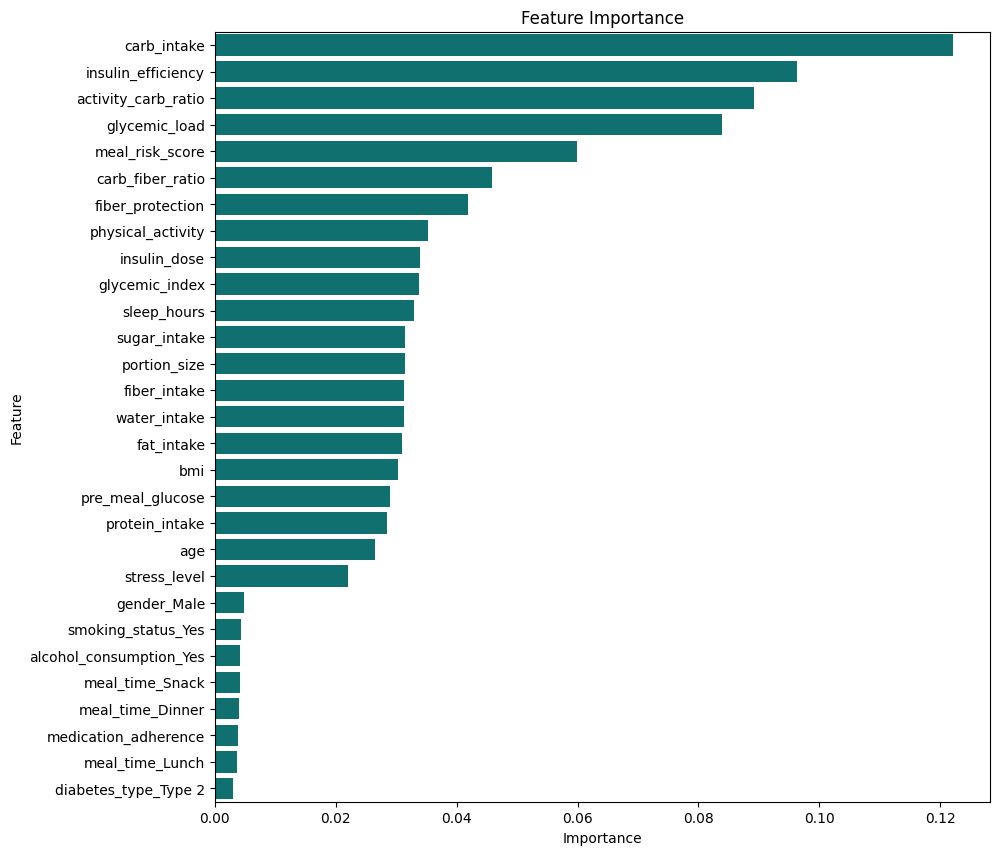

In [158]:
# Visulaize the feature importance

plt.figure(figsize=(10,10))
sns.barplot(x="Importance", y="Feature", color="teal", data=feature_importance)
plt.title('Feature Importance')
plt.show()

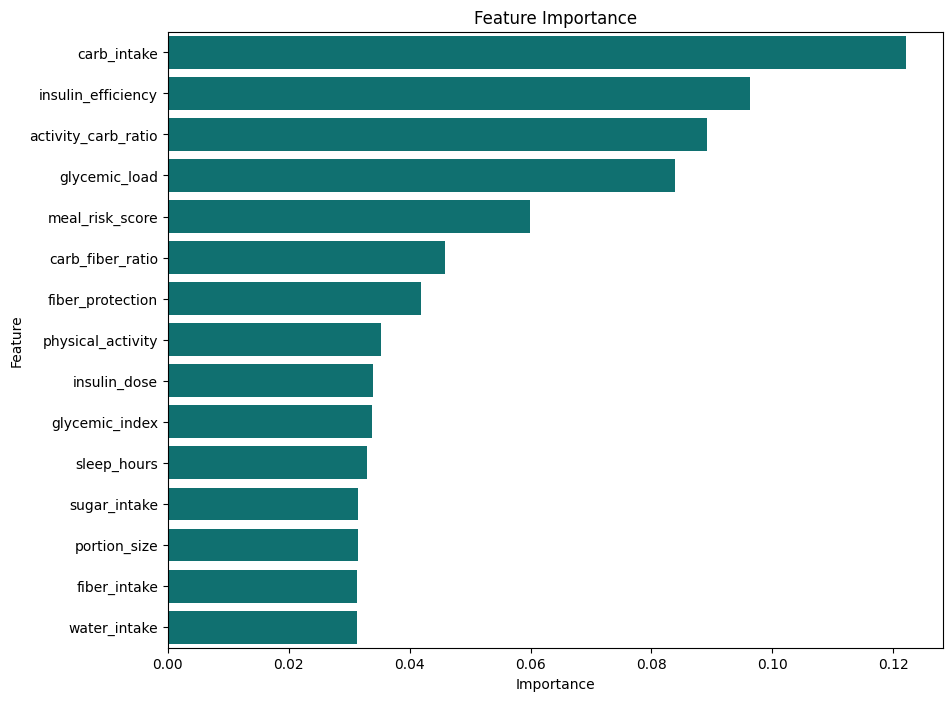

In [159]:
# Visulaize the feature importance (top 15)

plt.figure(figsize=(10,8))
sns.barplot(x="Importance", y="Feature", color="teal", data=feature_importance.head(15))
plt.title('Feature Importance')
plt.show()

      Top Predictors of Glucose Spikes relies mostly on diet and insulin-related factors: Carb Intake, Insulin Efficiency, Activity-Carb Ratio, Glycemic Load, Meal Risk Score. These features had very little influence on predictions: Gender, Smoking Status, Alcohol Consumption, Meal Time, Medication Adherence and Diabetes Type.

In [160]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


Accuracy: 0.7480
Precision: 0.7184
Recall: 0.7495
F1 Score: 0.7336
ROC-AUC: 0.8272

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.75      0.76       537
           1       0.72      0.75      0.73       463

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.75      0.75      0.75      1000



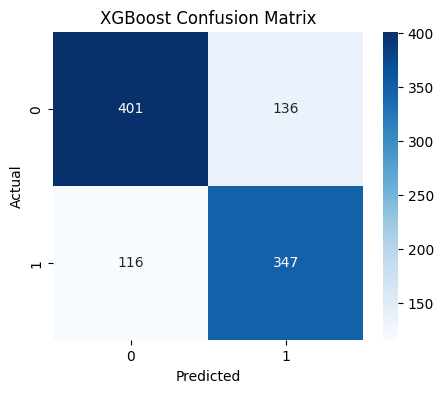

In [161]:
from xgboost import XGBClassifier

# Train XGBoost
xgb = XGBClassifier(random_state=42, eval_metric="logloss")

xgb.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)
roc_auc = roc_auc_score(y_test, y_prob_xgb)
report = classification_report(y_test, y_pred_xgb)
matrix = confusion_matrix(y_test, y_pred_xgb)

# Print Results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(report)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

      The XGBoost model achieved 74.8% accuracy, 71.8% precision, 75.0% recall, 73.4% F1-score, and 82.7% ROC-AUC. It correctly predicted 401 non-spike meals (True Negatives) and 347 spike meals (True Positives) while producing 136 false alarms (False Positives) and missing 116 actual spikes (False Negatives). Although XGBoost is a powerful machine learning algorithm, it performed worse than both Random Forest and Logistic Regression on this dataset.

##### Hyperparameter Tuning - Adjusting model settings (parameters) to get better performance¶

Tuning Logistic Regression

Best Hyperparameters for Logistic Regression: {'C': 0.01, 'solver': 'liblinear'}
Best Average Cross-Validation Score for Logistic Regression: 0.849086785072744
Accuracy: 0.7650
Precision: 0.7308
Recall: 0.7797
F1 Score: 0.7544
ROC-AUC: 0.8585

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.75      0.77       537
           1       0.73      0.78      0.75       463

    accuracy                           0.77      1000
   macro avg       0.76      0.77      0.76      1000
weighted avg       0.77      0.77      0.77      1000



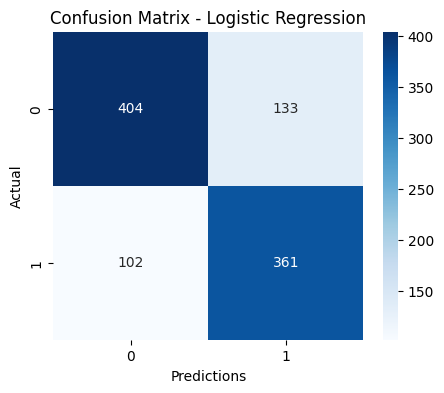

In [162]:
# Import Grid Search CV to optimize hyperparameters.
from sklearn.model_selection import GridSearchCV

# Define the model
lr = LogisticRegression(max_iter=5000, random_state=42)

# Define parameter grid
lr_param_grid = {'C': [0.01, 0.1, 1, 10, 100],'solver': ['lbfgs', 'liblinear']}

# Run grid search
grid_lr = GridSearchCV(lr, lr_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Train the model
grid_lr.fit(X_train, y_train)

# Best parameters
print(f"Best Hyperparameters for Logistic Regression: {grid_lr.best_params_}")
print(f"Best Average Cross-Validation Score for Logistic Regression: {grid_lr.best_score_}")

# Train the model
lr_best_model = grid_lr.best_estimator_

# Run predictions
y_pred_lrbest_model = lr_best_model.predict(X_test)
y_prob_lrbest_model = lr_best_model.predict_proba(X_test)[:,1]

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_lrbest_model)
precision = precision_score(y_test, y_pred_lrbest_model)
recall = recall_score(y_test, y_pred_lrbest_model)
f1 = f1_score(y_test, y_pred_lrbest_model)
roc_auc = roc_auc_score(y_test, y_prob_lrbest_model)
report = classification_report(y_test, y_pred_lrbest_model)

# Print Results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(report)
        

# Confustion matrix
lr_matrix = confusion_matrix(y_test, y_pred_lrbest_model)
plt.figure(figsize=(5,4)) 
sns.heatmap(lr_matrix, annot=True, fmt="d",cmap="Blues")
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

     The Tuned Logistic Regression model used the best hyperparameters C = 0.01 and solver = 'liblinear', achieving Cross-Validation Score of 84.9%, which indicates strong and stable performance. It achieved 76.5% accuracy, 73.1% precision, 78.0% recall, 75.4% F1-score, and 85.9% ROC-AUC. It correctly predicted 404 non-spike meals (True Negatives) and 361 spike meals (True Positives) while producing 133 false alarms (False Positives) and missing 102 actual spikes (False Negatives). Although tuning slightly reduced overall accuracy compared to the baseline Logistic Regression model, it improved recall and reduced missed spikes, making it more effective at identifying actual glucose spike events. 

##### Tuning Random Forest 

Best Hyperparameters for Random Forest: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best Average Cross-Validation Score for Random Forest : 0.8440004317081984
Accuracy: 0.7700
Precision: 0.7363
Recall: 0.7840
F1 Score: 0.7594
ROC-AUC: 0.8498

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       537
           1       0.74      0.78      0.76       463

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



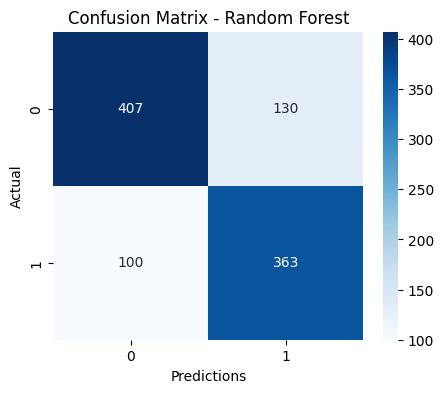

In [163]:
# Import Grid Search CV to optimize hyperparameters.
from sklearn.model_selection import GridSearchCV

# Define the model
rf = RandomForestClassifier(random_state=42)

# Define parameter grid
rf_param_grid = {"n_estimators": [100, 200, 300], "max_depth": [5, 10, 15, None], "min_samples_split": [2, 5, 10], "min_samples_leaf": [1, 2, 4]}

# Run grid search
grid_rf = GridSearchCV(rf, rf_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Train the model
grid_rf.fit(X_train, y_train)

# Best parameters
print(f"Best Hyperparameters for Random Forest: {grid_rf.best_params_}")
print(f"Best Average Cross-Validation Score for Random Forest : {grid_rf.best_score_}")

# Train the model
rf_best_model = grid_rf.best_estimator_

# Run predictions
y_pred_rfbest_model = rf_best_model.predict(X_test)
y_prob_rfbest_model = rf_best_model.predict_proba(X_test)[:,1]

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_rfbest_model)
precision = precision_score(y_test, y_pred_rfbest_model)
recall = recall_score(y_test, y_pred_rfbest_model)
f1 = f1_score(y_test, y_pred_rfbest_model)
roc_auc = roc_auc_score(y_test, y_prob_rfbest_model)
report = classification_report(y_test, y_pred_rfbest_model)

# Print Results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(report)
        

# Confustion matrix
rf_matrix = confusion_matrix(y_test, y_pred_rfbest_model)
plt.figure(figsize=(5,4))
sns.heatmap(rf_matrix, annot=True, fmt="d",cmap="Blues")
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

      The Tuned Random Forest model performed better than The Tuned Logistic Regression model for this glucose spike prediction project. It achieved Cross-Validation Score of 84.4%, 77.0% accuracy, 73.6% precision, 78.4% recall, 75.9% F1-score, and 85.0% ROC-AUC, while correctly predicting 407 non-spike meals (True Negatives) and 363 spike meals (True Positives). While producing 130 false alarms (False Positives), with only 100 missed spikes (False Negatives), it provides the strongest balance between prediction accuracy and clinical safety, making it the recommended model for deployment.

##### Tuning XGBoost

Best Hyperparameters for XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
Best Average Cross-Validation Score for XGBoost : 0.8458917160343224
Accuracy: 0.7730
Precision: 0.7408
Recall: 0.7840
F1 Score: 0.7618
ROC-AUC: 0.8532

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78       537
           1       0.74      0.78      0.76       463

    accuracy                           0.77      1000
   macro avg       0.77      0.77      0.77      1000
weighted avg       0.77      0.77      0.77      1000



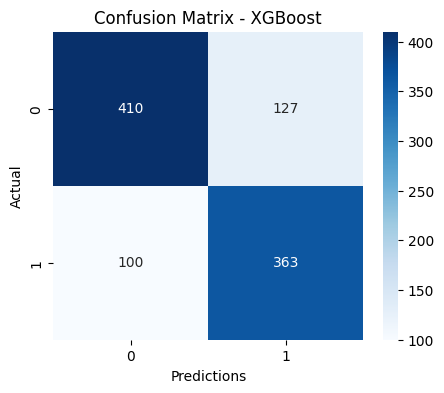

In [164]:
# Import Grid Search CV to optimize hyperparameters.
from sklearn.model_selection import GridSearchCV

# Define the model
xgb = XGBClassifier(random_state=42, eval_metric="logloss")

# Define parameter grid
xgb_param_grid = {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1]}

# Run grid search
grid_xgb = GridSearchCV(xgb, xgb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Train the model
grid_xgb.fit(X_train, y_train)

# Best parameters
print(f"Best Hyperparameters for XGBoost: {grid_xgb.best_params_}")
print(f"Best Average Cross-Validation Score for XGBoost : {grid_xgb.best_score_}")

# Train the model
xgb_best_model = grid_xgb.best_estimator_

# Run predictions
y_pred_xgbbest_model = xgb_best_model.predict(X_test)
y_prob_xgbbest_model = xgb_best_model.predict_proba(X_test)[:,1]

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred_xgbbest_model)
precision = precision_score(y_test, y_pred_xgbbest_model)
recall = recall_score(y_test, y_pred_xgbbest_model)
f1 = f1_score(y_test, y_pred_xgbbest_model)
roc_auc = roc_auc_score(y_test, y_prob_xgbbest_model)
report = classification_report(y_test, y_pred_xgbbest_model)

# Print Results
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")

print("\nClassification Report:")
print(report)
        

# Confustion matrix
xgb_matrix = confusion_matrix(y_test, y_pred_xgbbest_model)
plt.figure(figsize=(5,4))
sns.heatmap(xgb_matrix, annot=True, fmt="d",cmap="Blues")
plt.xlabel("Predictions")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.show()

     The Tuned XGBoost model achieved Cross-Validation Score of 84.5&, 77.3% accuracy, 74.1% precision, 78.4% recall, 76.2% F1-score, and 85.3% ROC-AUC. It correctly predicted 410 non-spike meals (True Negatives) and 363 spike meals (True Positives) while producing 127 false alarms (False Positives) and missing 100 actual spikes (False Negatives). Compared to the original XGBoost model, tuning produced substantial improvements across every metric, resulting in fewer mistakes and better spike detection. Overall, the Tuned XGBoost model emerged as the strongest performer, offering the best balance of predictive accuracy, reliability, and clinical usefulness for glucose spike prediction.

##### ROC Curve

ROC Curve Comparison

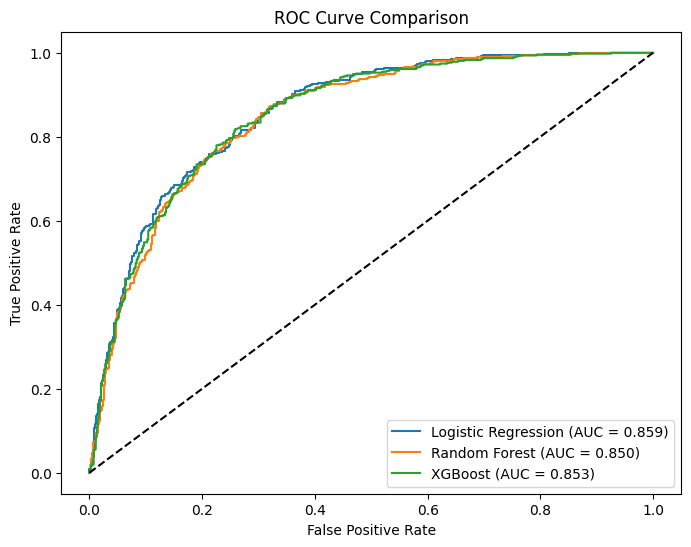

In [165]:
from sklearn.metrics import roc_curve

# Get probabilities
y_prob_lr = lr_best_model.predict_proba(X_test)[:,1]
y_prob_rf = rf_best_model.predict_proba(X_test)[:,1]
y_prob_xgb = xgb_best_model.predict_proba(X_test)[:,1]

# Calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

# Plot ROC curves
plt.figure(figsize=(8,6))

plt.plot(fpr_lr,tpr_lr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

     XGBoost provides the best overall prediction performance (highest accuracy, precision, and F1-Score), while Logistic Regression offers the best balance, with the highest ROC-AUC (85.9%), showing the strongest overall ability to distinguish glucose spikes from non-spikes.



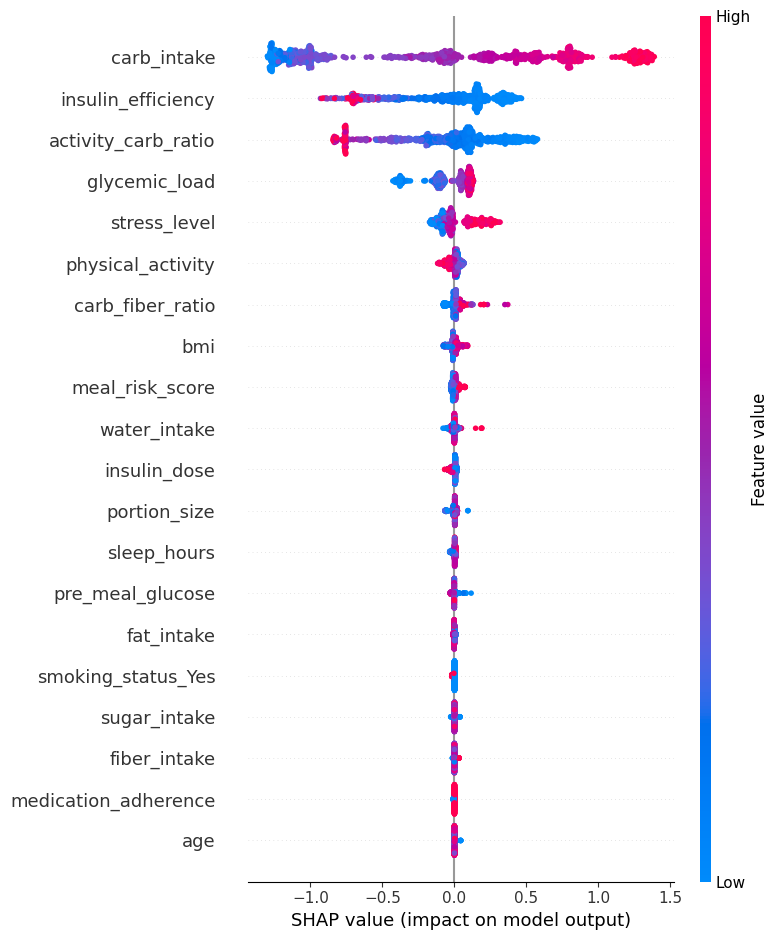

<bound method NDFrame.head of                     Feature  Mean_SHAP
2               carb_intake   0.777306
21       insulin_efficiency   0.280637
20      activity_carb_ratio   0.263323
16            glycemic_load   0.120619
13             stress_level   0.095052
12        physical_activity   0.024592
17         carb_fiber_ratio   0.022628
1                       bmi   0.020690
18          meal_risk_score   0.012080
9              water_intake   0.010143
10             insulin_dose   0.008494
8              portion_size   0.008374
14              sleep_hours   0.005241
15         pre_meal_glucose   0.004695
4                fat_intake   0.002735
27       smoking_status_Yes   0.002078
6              sugar_intake   0.002074
5              fiber_intake   0.001511
11     medication_adherence   0.001099
0                       age   0.000861
7            glycemic_index   0.000620
19         fiber_protection   0.000593
3            protein_intake   0.000000
23     diabetes_type_Type 2   0.00

In [166]:
import shap

# Define the model
xgb = XGBClassifier(random_state=42, eval_metric="logloss")

# Define parameter grid
xgb_param_grid = {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1]}

# Run grid search
grid_xgb = GridSearchCV(xgb, xgb_param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Train the model
grid_xgb.fit(X_train, y_train)

# Train the model
xgb_best_model = grid_xgb.best_estimator_

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_best_model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

feature_importance = pd.DataFrame({"Feature": X_test.columns, "Mean_SHAP": np.abs(shap_values).mean(axis=0)})
feature_importance = feature_importance.sort_values(by="Mean_SHAP", ascending=False)
feature_importance.head

     Meal composition and lifestyle behaviors are stronger predictors of glucose spikes than demographic factors.Top drivers were: Carb Intake, Insulin Efficiency, Activity-Carb Ratio, Glycemic Load and Stress Level. This indicates that glucose spike risk is largely influenced by what people eat, how active they are, and how effectively insulin is matched to carbohydrate intake.

##### Recommendation
- Reduce excessive carbohydrate consumption per meal.
- Combine carbohydrates with protein, healthy fats, and fiber to slow glucose absorption.
- Encourage stress-reduction techniques such as relaxation exercises, and adequate rest.
- Ensure insulin doses are appropriately matched to carbohydrate intake.
- Patiets should aim for balanced meals with adequate fiber content.
- Use patient-specific factors such as carbohydrate intake, activity level, insulin efficiency, and glycemic load to tailor dietary recommendations.